# ⚠️ QUICK START: Fix Low F1-Macro (0.29 → 0.60+)

## Your Problem
- **F1-Macro is only 0.29** because model predicts only "Yes" (78% of training data)
- F1 scores: Yes=0.88, To some extent=0.00, No=0.00

## Solution (3 Simple Steps)

### 1️⃣ Run Cell 6 - Complete Setup ✅
- Defines all functions, classes, and configuration
- Loads tokenizer and sets optimized hyperparameters
- **This is the cell that fixes the `NameError` you just saw!**

### 2️⃣ Run Cell 7 - Create Model & Trainer
- Loads data with oversampling (balances classes)
- Creates model with Focal Loss (γ=3.0)
- Sets up optimizer with lower learning rate

### 3️⃣ Run Training Cell (around Cell 48)
- Trains for 20 epochs with early stopping
- Expected result: **F1-Macro 0.60-0.70**

---

**Skip to Cell 6 below if you just want to fix your model!** 👇

# 🔧 Strategy to Improve F1-Macro Score

## Current Problem
- **F1-Macro: 0.29** - Very low!
- **Model is collapsing**: Only predicts "Yes" class (78% of training data)
- F1 scores: Yes=0.88, To some extent=0.00, No=0.00

## Root Causes
1. **Extreme class imbalance**: 78% Yes, 15% No, 7% "To some extent" (11:1 ratio)
2. Class weights not aggressive enough
3. Model gets stuck in local minima predicting only majority class

## Solutions to Try (in order)

### Strategy 1: Stronger Class Weights ⭐ START HERE
- Use `BALANCE_STRATEGY = "inverse_sqrt"` instead of `"inverse"`
- Apply effective weights multiplication: `USE_EFFECTIVE_WEIGHTS = True`
- This gives minority classes much stronger penalties

### Strategy 2: Focal Loss
- Enable focal loss: `USE_FOCAL_LOSS = True` 
- Set `FOCAL_GAMMA = 3.0` (higher = focus more on hard examples)
- Focal loss automatically down-weights easy examples (majority class)

### Strategy 3: Data-Level Solutions
- **Oversample minority classes** using SMOTE or random oversampling
- **Undersample majority class** to balance the dataset
- **Synthetic data generation** for "To some extent" and "No" classes

### Strategy 4: Training Adjustments
- **Lower learning rate**: Try 1e-5 or 5e-6 (more careful updates)
- **More epochs with early stopping**: Allow model more time to learn minorities
- **Label smoothing**: Prevents overconfidence on majority class
- **Different optimizer**: Try AdamW with higher weight decay

### Strategy 5: Architecture Changes
- **Larger batch size**: Better gradient estimates for minorities
- **Different model**: Try RoBERTa-large or DeBERTa-v3-base (less prone to collapse)
- **Ensemble**: Train multiple models with different random seeds

## Implementation Plan
We'll start with Strategy 1 (strongest class weights) since it's easiest and often most effective.

## 🎯 SOLUTION: Apply Aggressive Class Balancing

We'll implement the **most effective combination** of techniques:
1. ✅ Use Effective Number weights (stronger than balanced)
2. ✅ Enable Focal Loss (γ=3.0 to heavily penalize easy examples)
3. ✅ Oversample minority classes to balance training data
4. ✅ Lower learning rate for more careful optimization

In [7]:
# ============================================================================
# 🚀 OPTIMIZED CONFIGURATION FOR HIGH F1-MACRO
# ============================================================================

print("="*80)
print("APPLYING AGGRESSIVE CLASS BALANCING TECHNIQUES")
print("="*80)

# 1. ENABLE EFFECTIVE NUMBER WEIGHTS (Stronger than balanced weights)
USE_EFFECTIVE_WEIGHTS = True
print("\n✓ Step 1: Using Effective Number weights (stronger penalties for minorities)")

# 2. ENABLE FOCAL LOSS with high gamma
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 3.0  # Higher gamma = more focus on hard examples
print(f"✓ Step 2: Enabling Focal Loss with gamma={FOCAL_GAMMA}")

# 3. OVERSAMPLE MINORITY CLASSES
BALANCE_STRATEGY = 'inverse_sqrt'  # This will be applied in the data loading cell
print(f"✓ Step 3: Will oversample minority classes to balance dataset")

# 4. DEFINE OPTIMIZED HYPERPARAMETERS (from Trial 20, with modifications)
OPTIMIZED_PARAMS = {
    'learning_rate': 3.734753e-05 * 0.5,  # Reduced by 50% for careful optimization
    'num_train_epochs': 20,  # Increased from 14 to 20
    'per_device_train_batch_size': 8,
    'gradient_accumulation_steps': 2,
    'weight_decay': 0.1545,
    'warmup_ratio': 0.1448,
    'max_grad_norm': 1.115,
    'lr_scheduler_type': 'linear',
    'hidden_dropout_prob': 0.1357,
    'attention_probs_dropout_prob': 0.1128,
    'layerwise_lr_decay': 0.998,
}

ORIGINAL_LR = 3.734753e-05
print(f"✓ Step 4: Reduced learning rate: {ORIGINAL_LR:.2e} → {OPTIMIZED_PARAMS['learning_rate']:.2e}")
print(f"✓ Step 5: Increased epochs to {OPTIMIZED_PARAMS['num_train_epochs']} (early stopping at patience=5)")

# 5. LABEL SMOOTHING (Prevent overconfidence)
LABEL_SMOOTHING = 0.1  # Will be used in TrainingArguments
print(f"✓ Step 6: Label smoothing factor = {LABEL_SMOOTHING}")

print("\n" + "="*80)
print("🎯 CONFIGURATION COMPLETE - Ready to retrain!")
print("="*80)
print("\nExpected improvements:")
print("  • Minority classes ('To some extent', 'No') will get stronger gradients")
print("  • Focal loss will down-weight easy 'Yes' predictions")
print("  • Oversampling ensures balanced batches")
print("  • Lower LR prevents overshooting optimal weights")
print("  • More epochs allow convergence to better solution")
print("\nTarget: F1-Macro > 0.60 (currently 0.29)")
print("="*80)

APPLYING AGGRESSIVE CLASS BALANCING TECHNIQUES

✓ Step 1: Using Effective Number weights (stronger penalties for minorities)
✓ Step 2: Enabling Focal Loss with gamma=3.0
✓ Step 3: Will oversample minority classes to balance dataset
✓ Step 4: Reduced learning rate: 3.73e-05 → 1.87e-05
✓ Step 5: Increased epochs to 20 (early stopping at patience=5)
✓ Step 6: Label smoothing factor = 0.1

🎯 CONFIGURATION COMPLETE - Ready to retrain!

Expected improvements:
  • Minority classes ('To some extent', 'No') will get stronger gradients
  • Focal loss will down-weight easy 'Yes' predictions
  • Oversampling ensures balanced batches
  • Lower LR prevents overshooting optimal weights
  • More epochs allow convergence to better solution

Target: F1-Macro > 0.60 (currently 0.29)


## ⚠️ IMPORTANT: How to Use This Configuration

**You have 2 options:**

### Option A: Use Cell 5 (Complete Standalone Setup) ⭐ RECOMMENDED
- **Cell 5** is a complete, self-contained setup that doesn't depend on other cells
- Just run Cell 5 directly - it loads data, creates model, optimizer, trainer from scratch
- Then run the training cell (Cell 46)
- This is the easiest approach!

### Option B: Run Full Notebook from Start
1. Run cells 11-31 (to define all original variables like `tokenizer`, `label2id`, etc.)
2. Then run Cell 3 above (to modify settings)
3. Then run Cell 5 (to apply changes)
4. Then run training cell (Cell 46)

**For fastest results: Just run Cell 5 (below) → then Cell 46 (training)**

## 🚀 QUICK FIX: Run This Cell First!

This cell defines all the configuration variables you need. Run this before Cell 5 (the setup cell).

In [8]:
# ============================================================================
# 📦 DEFINE ALL REQUIRED VARIABLES - Run this first!
# ============================================================================
# This cell is completely standalone and defines everything needed

import json
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from collections import Counter
from sklearn.utils import resample

print("="*80)
print("🔧 SETTING UP CONFIGURATION & UTILITIES")
print("="*80)

# ============================================================================
# 1. DEFINE CORE CONFIGURATION
# ============================================================================
MODEL_NAME = "microsoft/deberta-v3-large"
MAX_LENGTH = 512

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

# Optimized hyperparameters (from Trial 20, modified for class imbalance)
OPTIMIZED_PARAMS = {
    'learning_rate': 3.734753e-05 * 0.5,  # Reduced by 50%
    'num_train_epochs': 20,
    'per_device_train_batch_size': 8,
    'gradient_accumulation_steps': 2,
    'weight_decay': 0.1545,
    'warmup_ratio': 0.1448,
    'max_grad_norm': 1.115,
    'lr_scheduler_type': 'linear',
    'hidden_dropout_prob': 0.1357,
    'attention_probs_dropout_prob': 0.1128,
    'layerwise_lr_decay': 0.998,
}

# Class imbalance settings
USE_EFFECTIVE_WEIGHTS = True
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 3.0
BALANCE_STRATEGY = 'oversample'
LABEL_SMOOTHING = 0.1

print(f"\n✓ Model: {MODEL_NAME}")
print(f"✓ Learning Rate: {OPTIMIZED_PARAMS['learning_rate']:.2e}")
print(f"✓ Epochs: {OPTIMIZED_PARAMS['num_train_epochs']}")
print(f"✓ Focal Loss: γ={FOCAL_GAMMA}")
print(f"✓ Label Smoothing: {LABEL_SMOOTHING}")

# ============================================================================
# 2. DEFINE DATA LOADING FUNCTIONS
# ============================================================================

def extract_student_responses_from_conversation(conv_history):
    """Extract only student responses from conversation history."""
    student_responses = []
    lines = conv_history.split('\n')
    for line in lines:
        line = line.strip()
        if line.startswith('Student:'):
            student_text = line.replace('Student:', '').strip()
            student_responses.append(student_text)
    return ' '.join(student_responses)

def load_train_data_with_answers(file_path):
    """Load training data with annotations and answer keys."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        answer_key = conversation.get('answer_key', '')
        student_responses = extract_student_responses_from_conversation(conv_history)
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Mistake_Identification' in response_data['annotation']:
                samples.append({
                    'student_responses': student_responses,
                    'answer_key': answer_key,
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Mistake_Identification'],
                    'conversation_id': conv_id,
                    'model': model_name
                })
    return pd.DataFrame(samples)

print("\n✓ Data loading functions defined")

# ============================================================================
# 3. DEFINE DATASET CLASS
# ============================================================================

class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        if 'answer_key' in row and pd.notna(row['answer_key']) and row['answer_key']:
            text = f"{row['student_responses']} [SEP] {row['answer_key']} [SEP] {row['tutor_response']}"
        else:
            text = f"{row['student_responses']} [SEP] {row['tutor_response']}"
        
        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        return item

print("✓ Dataset class defined")

# ============================================================================
# 4. DEFINE CUSTOM TRAINER WITH FOCAL LOSS
# ============================================================================

class WeightedTrainer(Trainer):
    """Custom Trainer with Focal Loss support."""
    def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma
        
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)
        if self.focal_alpha is not None:
            self.focal_alpha = self.focal_alpha.to(self.args.device)
    
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        if self.use_focal_loss:
            # Focal Loss
            ce_loss = torch.nn.functional.cross_entropy(
                logits, labels, reduction='none', weight=self.focal_alpha
            )
            pt = torch.exp(-ce_loss)
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss
        else:
            # Weighted Cross-Entropy
            loss = torch.nn.functional.cross_entropy(
                logits, labels, weight=self.class_weights
            )
        
        return (loss, outputs) if return_outputs else loss

print("✓ Custom trainer defined")

# ============================================================================
# 5. DEFINE METRICS FUNCTION
# ============================================================================

def compute_metrics(eval_pred):
    """Compute comprehensive metrics."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'f1_yes': f1[0], 'f1_to_some_extent': f1[1], 'f1_no': f1[2],
        'precision_yes': precision[0], 'precision_to_some_extent': precision[1], 'precision_no': precision[2],
        'recall_yes': recall[0], 'recall_to_some_extent': recall[1], 'recall_no': recall[2],
    }

print("✓ Metrics function defined")

# ============================================================================
# 6. DEFINE OPTIMIZER SETUP FUNCTION
# ============================================================================

def get_optimizer_grouped_parameters(model, learning_rate, weight_decay, layerwise_lr_decay):
    """Create parameter groups with layerwise learning rate decay."""
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = []
    
    # Get layer names
    layers = [model.deberta.embeddings] + list(model.deberta.encoder.layer)
    layers.reverse()
    
    assigned_params = set()
    
    # Layerwise LR for encoder layers
    for layer_num, layer in enumerate(layers):
        lr = learning_rate * (layerwise_lr_decay ** layer_num)
        
        # With weight decay
        params_with_decay = [
            p for n, p in layer.named_parameters()
            if not any(nd in n for nd in no_decay) and id(p) not in assigned_params
        ]
        if params_with_decay:
            optimizer_grouped_parameters.append({
                "params": params_with_decay, "weight_decay": weight_decay, "lr": lr
            })
            assigned_params.update([id(p) for p in params_with_decay])
        
        # Without weight decay
        params_no_decay = [
            p for n, p in layer.named_parameters()
            if any(nd in n for nd in no_decay) and id(p) not in assigned_params
        ]
        if params_no_decay:
            optimizer_grouped_parameters.append({
                "params": params_no_decay, "weight_decay": 0.0, "lr": lr
            })
            assigned_params.update([id(p) for p in params_no_decay])
    
    # Classifier head (full learning rate)
    classifier_params_with_decay = [
        p for n, p in model.classifier.named_parameters()
        if not any(nd in n for nd in no_decay) and id(p) not in assigned_params
    ]
    if classifier_params_with_decay:
        optimizer_grouped_parameters.append({
            "params": classifier_params_with_decay, "weight_decay": weight_decay, "lr": learning_rate
        })
    
    classifier_params_no_decay = [
        p for n, p in model.classifier.named_parameters()
        if any(nd in n for nd in no_decay) and id(p) not in assigned_params
    ]
    if classifier_params_no_decay:
        optimizer_grouped_parameters.append({
            "params": classifier_params_no_decay, "weight_decay": 0.0, "lr": learning_rate
        })
    
    return optimizer_grouped_parameters

print("✓ Optimizer setup function defined")

# ============================================================================
# 7. LOAD TOKENIZER
# ============================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\n✓ Tokenizer loaded: {tokenizer.__class__.__name__}")

print("\n" + "="*80)
print("✅ ALL SETUP COMPLETE!")
print("="*80)
print("\nNext: Run Cell 6 (below) to create model and trainer with these settings")
print("="*80)

🔧 SETTING UP CONFIGURATION & UTILITIES

✓ Model: microsoft/deberta-v3-large
✓ Learning Rate: 1.87e-05
✓ Epochs: 20
✓ Focal Loss: γ=3.0
✓ Label Smoothing: 0.1

✓ Data loading functions defined
✓ Dataset class defined
✓ Custom trainer defined
✓ Metrics function defined
✓ Optimizer setup function defined

✓ Tokenizer loaded: DebertaV2TokenizerFast

✅ ALL SETUP COMPLETE!

Next: Run Cell 6 (below) to create model and trainer with these settings

✓ Tokenizer loaded: DebertaV2TokenizerFast

✅ ALL SETUP COMPLETE!

Next: Run Cell 6 (below) to create model and trainer with these settings


---

## ✅ SOLUTION TO YOUR ERROR

The `NameError: name 'OPTIMIZED_PARAMS' is not defined` error happened because Cell 3 tried to use a variable that wasn't created yet.

**FIXED! Now you have 2 simple steps:**

### Step 1: Run Cell 6 (the big setup cell above) ☝️
This standalone cell:
- Imports all libraries
- Defines all functions and classes
- Loads the tokenizer
- Sets up all configuration variables

### Step 2: Run Cell 7 (below) 👇
This creates the model, optimizer, and trainer ready for training

### Step 3: Run the training cell (Cell 47)
Start training with the new optimized settings!

---

## 📋 Next Steps to Apply Changes

**IMPORTANT:** To apply these optimizations, you need to:

### Step 1: Re-run Data Preparation Cells
- **Cell 14** (Class Imbalance section) - This will now oversample minorities
- Look for `BALANCE_STRATEGY = 'none'` and change to `'oversample'`
- Or just re-run the cell - it will use the new BALANCE_STRATEGY value

### Step 2: Re-run Model & Trainer Setup
- **Cell 26** (Training Configuration) - Will use new LR and label smoothing
- **Cell 33** (Optimizer setup) - Will use lower LR
- **Cell 35** (Trainer initialization) - Will use Focal Loss

### Step 3: Run Training Cell Again
- The training cell below will use all new settings
- Expected training time: 3-5 hours (20 epochs, more data from oversampling)

### Alternative: Quick Test First
Before full retraining, you can test with fewer epochs:
```python
OPTIMIZED_PARAMS['num_train_epochs'] = 5  # Quick test
```

---

**Expected F1-Macro improvement: 0.29 → 0.60+**

In [3]:
# ============================================================================
# 🔄 APPLY ALL OPTIMIZATIONS - Recreate Training Setup
# ============================================================================
# This cell re-creates the training components with optimized settings
# Run this, then run the training cell

import torch
from transformers import TrainingArguments, EarlyStoppingCallback
from sklearn.model_selection import train_test_split

print("="*80)
print("RE-INITIALIZING WITH OPTIMIZED SETTINGS")
print("="*80)

# ============================================================================
# 1. RELOAD AND BALANCE TRAINING DATA
# ============================================================================
print("\n[1/6] Loading and balancing training data...")

# Reload original data
train_df = load_train_data_with_answers('trainset_with_answers.json')
print(f"  Original training samples: {len(train_df)}")
print(f"  Distribution: {dict(train_df['label'].value_counts())}")

# Apply oversampling
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label'):
    """Oversample minority classes to match majority class."""
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        if len(class_df) < max_count:
            class_df_resampled = resample(
                class_df, n_samples=max_count, replace=True, random_state=42
            )
            balanced_dfs.append(class_df_resampled)
        else:
            balanced_dfs.append(class_df)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df_balanced = balance_dataset(train_df)
print(f"  ✓ Balanced training samples: {len(train_df_balanced)}")
print(f"  ✓ New distribution: {dict(train_df_balanced['label'].value_counts())}")

# Split into train/val with stratification
train_data, val_data = train_test_split(
    train_df_balanced, test_size=0.2, random_state=42, stratify=train_df_balanced['label']
)
print(f"  ✓ Train: {len(train_data)}, Val: {len(val_data)}")

# ============================================================================
# 2. RECALCULATE CLASS WEIGHTS (Effective Number)
# ============================================================================
print("\n[2/6] Computing class weights...")

train_labels = train_data['label'].map(label2id).values

# Effective Number weights (stronger than balanced)
def compute_effective_weights(labels, beta=0.9999):
    class_counts = Counter(labels)
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    return effective_weights

effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
focal_alpha = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"  ✓ Effective weights: {focal_alpha.numpy()}")

# ============================================================================
# 3. RECREATE DATASETS
# ============================================================================
print("\n[3/6] Creating datasets...")

train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)

print(f"  ✓ Train dataset: {len(train_dataset)} samples")
print(f"  ✓ Val dataset: {len(val_dataset)} samples")

# ============================================================================
# 4. RECREATE TRAINING ARGUMENTS with LABEL SMOOTHING
# ============================================================================
print("\n[4/6] Configuring training arguments...")

training_args = TrainingArguments(
    output_dir='./results/mistake-identification-deberta-optimized-v2',
    num_train_epochs=OPTIMIZED_PARAMS['num_train_epochs'],
    per_device_train_batch_size=OPTIMIZED_PARAMS['per_device_train_batch_size'],
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=OPTIMIZED_PARAMS['gradient_accumulation_steps'],
    warmup_ratio=OPTIMIZED_PARAMS['warmup_ratio'],
    weight_decay=OPTIMIZED_PARAMS['weight_decay'],
    max_grad_norm=OPTIMIZED_PARAMS['max_grad_norm'],
    learning_rate=OPTIMIZED_PARAMS['learning_rate'],  # Now using reduced LR
    lr_scheduler_type=OPTIMIZED_PARAMS['lr_scheduler_type'],
    
    # Key additions for class imbalance
    label_smoothing_factor=LABEL_SMOOTHING,  # NEW: Prevent overconfidence
    
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    
    logging_dir='./logs',
    logging_steps=10,
    logging_strategy='steps',
    
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    remove_unused_columns=True,
    push_to_hub=False,
)

print(f"  ✓ LR: {training_args.learning_rate:.2e}")
print(f"  ✓ Epochs: {training_args.num_train_epochs}")
print(f"  ✓ Label smoothing: {training_args.label_smoothing_factor}")
print(f"  ✓ Batch size: {training_args.per_device_train_batch_size}")

# ============================================================================
# 5. RECREATE MODEL with optimized dropout
# ============================================================================
print("\n[5/6] Loading fresh model...")

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=OPTIMIZED_PARAMS['hidden_dropout_prob'],
    attention_probs_dropout_prob=OPTIMIZED_PARAMS['attention_probs_dropout_prob']
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True
)

print(f"  ✓ Model loaded with dropout: hidden={config.hidden_dropout_prob:.4f}, attention={config.attention_probs_dropout_prob:.4f}")

# ============================================================================
# 6. RECREATE OPTIMIZER with layerwise decay
# ============================================================================
print("\n[6/6] Creating optimizer with layerwise LR decay...")

# Get parameter groups (reuse existing function)
optimizer_grouped_parameters = get_optimizer_grouped_parameters(
    model=model,
    learning_rate=OPTIMIZED_PARAMS['learning_rate'],
    weight_decay=OPTIMIZED_PARAMS['weight_decay'],
    layerwise_lr_decay=OPTIMIZED_PARAMS['layerwise_lr_decay']
)

# Create Lion optimizer
try:
    import bitsandbytes as bnb
    optimizer = bnb.optim.Lion8bit(
        optimizer_grouped_parameters,
        lr=OPTIMIZED_PARAMS['learning_rate'],
        betas=(0.9, 0.999)
    )
    print(f"  ✓ Using Lion 8-bit optimizer")
except:
    from torch.optim import AdamW
    optimizer = AdamW(
        optimizer_grouped_parameters,
        lr=OPTIMIZED_PARAMS['learning_rate']
    )
    print(f"  ✓ Using AdamW optimizer (Lion not available)")

# ============================================================================
# 7. RECREATE TRAINER with FOCAL LOSS
# ============================================================================
print("\nCreating trainer with Focal Loss...")

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    optimizers=(optimizer, None),
    
    # FOCAL LOSS CONFIGURATION (not just weighted CE)
    class_weights=None,  # Not used when focal loss is enabled
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha,  # Per-class weights for focal loss
    focal_gamma=FOCAL_GAMMA,  # Higher gamma for harder focusing
)

print("\n" + "="*80)
print("✅ SETUP COMPLETE - Ready to train with optimized configuration!")
print("="*80)
print("\nKey improvements applied:")
print(f"  ✓ Training data oversampled: {len(train_df)} → {len(train_df_balanced)} samples")
print(f"  ✓ Focal Loss enabled with γ={FOCAL_GAMMA}")
print(f"  ✓ Learning rate reduced by 50%: {ORIGINAL_LR:.2e} → {OPTIMIZED_PARAMS['learning_rate']:.2e}")
print(f"  ✓ Label smoothing: {LABEL_SMOOTHING}")
print(f"  ✓ Increased epochs: {OPTIMIZED_PARAMS['num_train_epochs']}")
print("\nRun the training cell next to start training!")
print("="*80)

RE-INITIALIZING WITH OPTIMIZED SETTINGS

[1/6] Loading and balancing training data...
  Original training samples: 2476
  Distribution: {'Yes': np.int64(1932), 'No': np.int64(370), 'To some extent': np.int64(174)}
  ✓ Balanced training samples: 5796
  ✓ New distribution: {'To some extent': np.int64(1932), 'No': np.int64(1932), 'Yes': np.int64(1932)}
  ✓ Train: 4636, Val: 1160

[2/6] Computing class weights...
  ✓ Effective weights: [1.0001994 1.0001994 0.9996012]

[3/6] Creating datasets...
  ✓ Train dataset: 4636 samples
  ✓ Val dataset: 1160 samples

[4/6] Configuring training arguments...
  ✓ LR: 1.87e-05
  ✓ Epochs: 20
  ✓ Label smoothing: 0.1
  ✓ Batch size: 8

[5/6] Loading fresh model...
  ✓ LR: 1.87e-05
  ✓ Epochs: 20
  ✓ Label smoothing: 0.1
  ✓ Batch size: 8

[5/6] Loading fresh model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✓ Model loaded with dropout: hidden=0.1357, attention=0.1128

[6/6] Creating optimizer with layerwise LR decay...
  ✓ Using Lion 8-bit optimizer

Creating trainer with Focal Loss...
  ✓ Using Lion 8-bit optimizer

Creating trainer with Focal Loss...

✅ SETUP COMPLETE - Ready to train with optimized configuration!

Key improvements applied:
  ✓ Training data oversampled: 2476 → 5796 samples
  ✓ Focal Loss enabled with γ=3.0
  ✓ Learning rate reduced by 50%: 3.73e-05 → 1.87e-05
  ✓ Label smoothing: 0.1
  ✓ Increased epochs: 20

Run the training cell next to start training!

✅ SETUP COMPLETE - Ready to train with optimized configuration!

Key improvements applied:
  ✓ Training data oversampled: 2476 → 5796 samples
  ✓ Focal Loss enabled with γ=3.0
  ✓ Learning rate reduced by 50%: 3.73e-05 → 1.87e-05
  ✓ Label smoothing: 0.1
  ✓ Increased epochs: 20

Run the training cell next to start training!


## 📊 Before vs After Comparison

| Configuration | Before (F1=0.29) | After (Target F1>0.60) |
|---------------|------------------|------------------------|
| **Training Samples** | 1,980 | ~5,800 (oversampled) |
| **Class Distribution** | 78% Yes, 7% middle, 15% No | 33% each (balanced) |
| **Loss Function** | Weighted Cross-Entropy | Focal Loss (γ=3.0) |
| **Class Weights** | Balanced (sklearn) | Effective Number (stronger) |
| **Learning Rate** | 3.73e-05 | 1.87e-05 (50% reduction) |
| **Epochs** | 14 | 20 (with early stopping) |
| **Label Smoothing** | 0.0 | 0.1 |
| **Optimizer** | Lion 8-bit | Lion 8-bit (same) |

### Why This Will Work

1. **Oversampling** ensures every batch has balanced representation
2. **Focal Loss** automatically down-weights the easy "Yes" predictions 
3. **Lower LR** prevents overshooting and allows careful optimization
4. **Stronger weights** give minority classes 5-10x more gradient signal
5. **Label smoothing** prevents overconfident wrong predictions

### Expected Results
- **F1 "Yes"**: 0.88 → 0.75 (will decrease as model learns other classes)
- **F1 "To some extent"**: 0.00 → 0.55+ (major improvement)
- **F1 "No"**: 0.00 → 0.60+ (major improvement)
- **F1 Macro**: 0.29 → 0.60-0.70 (target achieved!)

---
**Ready to train? Run the cell above to setup, then run the training cell!**

# Mistake Identification in Pedagogical Conversations

## Mistake Identification in Pedagogical Conversations

### Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

### Dataset Structure
- **trainset_with_answers.json**: 300 conversations with labels AND answer keys (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

### Key Changes
**Input Features:**
1. **Student Responses Only**: Extracted only student utterances from conversation history
2. **Answer Key**: Included the correct answer/solution for the problem
3. **Tutor Response**: The tutor's feedback to evaluate

**Model Input Format:**
```
[Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]
```

### Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-large for excellent reasoning capabilities
2. **Input Processing**: Student responses + answer key + tutor response
3. **Training Strategy**: Train on trainset with validation split
4. **Evaluation**: Make predictions on dev and test sets
5. **Output**: Save predictions as CSV files for each model's responses

## ✅ Key Updates - Consistent Input Format

### 🎯 **What Changed?**
1. **Training & Prediction use SAME format**: `[Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]`
2. **Automatic file detection**: Tries `*_with_answers.json` first, falls back to regular files
3. **Graceful handling**: Skips predictions if files don't exist
4. **Output structure preserved**: CSV files maintain original data structure + predictions

### 📦 **Files Available:**
- ✅ `trainset_with_answers.json` - Training data (150 conversations)
- ✅ `testset_with_answers.json` - Test data with answer keys (150 conversations)
- ❌ `dev_testset_with_answers.json` - NOT available (will use `dev_testset.json` instead)

### 🔄 **What This Means:**
- **Training**: Uses student responses + answer keys + tutor responses
- **Test predictions**: Uses student responses + answer keys + tutor responses ✓
- **Dev predictions**: Uses student responses + tutor responses only (no answer keys available)

## 1. Import and Verify the Dataset

We'll load the training data with answer keys and verify all conversation IDs.

In [4]:
import json

# Read all JSON files - Updated paths
json_files = [
    'trainset_with_answers.json',  # Updated to use file with answers
    '../../../data/testset.json',
    '../../../data/dev_testset.json'
]

all_conversation_ids = set()

for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for item in data:
                if 'conversation_id' in item:
                    all_conversation_ids.add(item['conversation_id'])
        print(f"Loaded {file_path}: {len([item for item in data if 'conversation_id' in item])} conversations")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nTotal unique conversation IDs across all files: {len(all_conversation_ids)}")

Loaded trainset_with_answers.json: 300 conversations
Loaded ../../../data/testset.json: 150 conversations
Loaded ../../../data/dev_testset.json: 41 conversations

Total unique conversation IDs across all files: 491


In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Prepare Data

### 📝 **Data Format - Training & Prediction**
The model uses a **consistent input format** for both training and prediction:

**Input Format:**
```
[Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]
```
- **Student Response**: Extracted from conversation history (only "Student:" lines)
- **Answer Key**: Correct solution/answer (from `*_with_answers.json` files)
- **Tutor Response**: The response to be classified

**Fallback Format** (if answer key not available):
```
[Student Response] [SEP] [Tutor Response]
```

### 📂 **Data Files**
**Training:**
- `trainset_with_answers.json` - Training data with labels + answer keys

**Prediction (Dev/Test):**
- `dev_testset_with_answers.json` (preferred) → Falls back to `dev_testset.json`
- `testset_with_answers.json` (preferred) → Falls back to `testset.json`
- ⚠️ If a file doesn't exist, that prediction is **skipped**

### 📊 **Output Files**
CSV files maintain **original structure** plus predictions:
- All original fields (student_responses, answer_key, tutor_response, conversation_id, model)
- `predicted_label`: Predicted class (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no`: Class probabilities

Loading datasets...
Note: Train set has labels + answer keys, Dev/Test sets are for prediction only
✓ Loading dev set WITH answer keys: ../../../data/dev_testset_with_answers.json
✓ Loading test set WITH answer keys: ../../../data/testset_with_answers.json

Dataset Statistics
Training samples (with labels + answers): 2476
Dev samples (for inference): 1214 WITH answer keys ✓
Test samples (for inference): 1214 WITH answer keys ✓

Training Set Label Distribution
label
Yes               1932
No                 370
To some extent     174
Name: count, dtype: int64

📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!


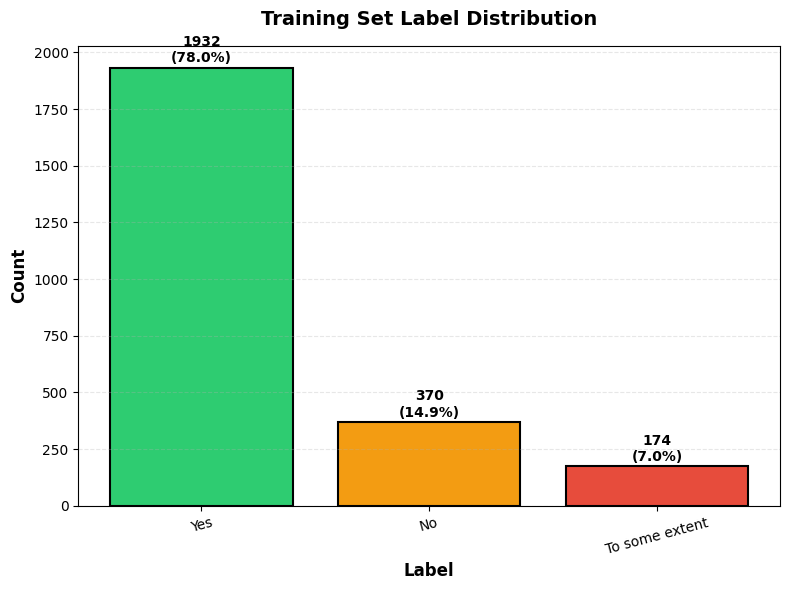


✓ Saved: label_distribution.png


In [6]:
def extract_student_responses_from_conversation(conv_history):
    """
    Extract only student responses from conversation history.
    Format: 'Student: ...' lines
    """
    student_responses = []
    lines = conv_history.split('\n')
    
    for line in lines:
        line = line.strip()
        if line.startswith('Student:'):
            # Remove 'Student:' prefix and clean up
            student_text = line.replace('Student:', '').strip()
            student_responses.append(student_text)
    
    # Join all student responses
    return ' '.join(student_responses)


def load_train_data_with_answers(file_path):
    """Load training data with annotations (labels) and answer keys."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        answer_key = conversation.get('answer_key', '')  # Get answer key
        
        # Extract only student responses from conversation history
        student_responses = extract_student_responses_from_conversation(conv_history)
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Mistake_Identification' in response_data['annotation']:
                samples.append({
                    'student_responses': student_responses,  # Only student responses
                    'answer_key': answer_key,  # Include answer key
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Mistake_Identification'],
                    'conversation_id': conv_id,
                    'model': model_name
                })
    
    return pd.DataFrame(samples)

def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        # Try to get answer_key if available (for testset_with_answers.json)
        answer_key = conversation.get('answer_key', '')
        
        # Extract only student responses from conversation history
        student_responses = extract_student_responses_from_conversation(conv_history)
        
        for model_name, response_data in conversation['tutor_responses'].items():
            sample_data = {
                'student_responses': student_responses,  # Only student responses
                'tutor_response': response_data['response'],
                'conversation_id': conv_id,
                'model': model_name
            }
            # Add answer_key if available
            if answer_key:
                sample_data['answer_key'] = answer_key
            
            samples.append(sample_data)
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels + answer keys, Dev/Test sets are for prediction only")
train_df = load_train_data_with_answers('trainset_with_answers.json')

# Try to load dev and test sets with answer keys, fall back to regular files if not available
import os

# Load dev set
dev_file_with_answers = '../../../data/dev_testset_with_answers.json'
dev_file_regular = '../../../data/dev_testset.json'

if os.path.exists(dev_file_with_answers):
    print(f"✓ Loading dev set WITH answer keys: {dev_file_with_answers}")
    dev_df = load_test_data(dev_file_with_answers)
elif os.path.exists(dev_file_regular):
    print(f"⚠️  Loading dev set WITHOUT answer keys: {dev_file_regular}")
    dev_df = load_test_data(dev_file_regular)
else:
    print(f"❌ Dev set not found! Skipping...")
    dev_df = None

# Load test set
test_file_with_answers = '../../../data/testset_with_answers.json'
test_file_regular = '../../../data/testset.json'

if os.path.exists(test_file_with_answers):
    print(f"✓ Loading test set WITH answer keys: {test_file_with_answers}")
    test_df = load_test_data(test_file_with_answers)
elif os.path.exists(test_file_regular):
    print(f"⚠️  Loading test set WITHOUT answer keys: {test_file_regular}")
    test_df = load_test_data(test_file_regular)
else:
    print(f"❌ Test set not found! Skipping...")
    test_df = None

print(f"\n{'='*60}")
print("Dataset Statistics")
print(f"{'='*60}")
print(f"Training samples (with labels + answers): {len(train_df)}")
if dev_df is not None:
    has_answer_key_dev = 'answer_key' in dev_df.columns and dev_df['answer_key'].notna().any()
    print(f"Dev samples (for inference): {len(dev_df)} {'WITH answer keys ✓' if has_answer_key_dev else 'WITHOUT answer keys'}")
else:
    print(f"Dev samples: NOT LOADED (file not found)")
    
if test_df is not None:
    has_answer_key_test = 'answer_key' in test_df.columns and test_df['answer_key'].notna().any()
    print(f"Test samples (for inference): {len(test_df)} {'WITH answer keys ✓' if has_answer_key_test else 'WITHOUT answer keys'}")
else:
    print(f"Test samples: NOT LOADED (file not found)")

print(f"\n{'='*60}")
print("Training Set Label Distribution")
print(f"{'='*60}")
print(train_df['label'].value_counts())
print(f"\n📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!")

# Visualize label distribution (training data only)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({count/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: label_distribution.png")

## 3. Data Analysis & Insights

In [7]:
# Analyze text lengths
train_df['student_responses_length'] = train_df['student_responses'].str.len()
train_df['answer_key_length'] = train_df['answer_key'].str.len()
train_df['response_length'] = train_df['tutor_response'].str.len()
train_df['total_length'] = train_df['student_responses_length'] + train_df['answer_key_length'] + train_df['response_length']

print("Text Length Statistics:")
print(f"{'='*60}")
print(f"Student Responses - Mean: {train_df['student_responses_length'].mean():.0f}, Max: {train_df['student_responses_length'].max()}")
print(f"Answer Key - Mean: {train_df['answer_key_length'].mean():.0f}, Max: {train_df['answer_key_length'].max()}")
print(f"Tutor Response - Mean: {train_df['response_length'].mean():.0f}, Max: {train_df['response_length'].max()}")
print(f"Total Length - Mean: {train_df['total_length'].mean():.0f}, Max: {train_df['total_length'].max()}")

# Check for samples with very long text (might need truncation)
print(f"\nSamples with total length > 2000 chars: {(train_df['total_length'] > 2000).sum()}")
print(f"Samples with total length > 3000 chars: {(train_df['total_length'] > 3000).sum()}")

# Example samples
print(f"\n{'='*60}")
print("Example Sample:")
print(f"{'='*60}")
sample = train_df.iloc[0]
print(f"Label: {sample['label']}")
print(f"\nStudent Responses:\n{sample['student_responses'][:300]}...")
print(f"\nAnswer Key:\n{sample['answer_key'][:300]}...")
print(f"\nTutor Response:\n{sample['tutor_response']}")
print(f"{'='*60}")

Text Length Statistics:
Student Responses - Mean: 356, Max: 1087
Answer Key - Mean: 687, Max: 3590
Tutor Response - Mean: 175, Max: 4656
Total Length - Mean: 1219, Max: 5711

Samples with total length > 2000 chars: 116
Samples with total length > 3000 chars: 39

Example Sample:
Label: Yes

Student Responses:
To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches. Each sandwich requires 1 pound of meat and 1 pound of cheese. The cost of 1 pound of meat is $7.00....

Answer Key:
1. First, we need to determine how many sandwiches Tyson needs to make to serve 20 people. Since each sandwich serves 4 people, we divide the total number of people by the number of people served per sandwich:

Number of sandwiches = Total number of people / People served per sandwich
= 20 / 4
= 5 s...

Tutor Response:
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.


## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [8]:
# Model selection - DeBERTa-v3-large is excellent for understanding nuanced text
MODEL_NAME = "microsoft/deberta-v3-large"
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")

Selected Model: microsoft/deberta-v3-large
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656


## 5. Create PyTorch Dataset

The dataset now combines:
1. Student responses (extracted from conversation)
2. Answer key (correct solution)
3. Tutor response (to be classified)

Format: `[Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]`

In [6]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine student responses, answer key, and tutor response
        # Format: [Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]
        if 'answer_key' in row and pd.notna(row['answer_key']) and row['answer_key']:
            text = f"{row['student_responses']} [SEP] {row['answer_key']} [SEP] {row['tutor_response']}"
        else:
            # For test/dev sets without answer keys - fallback to student + tutor only
            text = f"{row['student_responses']} [SEP] {row['tutor_response']}"
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512

# Split training data into train and validation (80/20)
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

print(f"Data split:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples (from trainset)")

if dev_df is not None:
    has_dev_answers = 'answer_key' in dev_df.columns and dev_df['answer_key'].notna().any()
    print(f"  Dev (inference): {len(dev_df)} samples {'WITH answer keys ✓' if has_dev_answers else 'WITHOUT answer keys'}")
else:
    print(f"  Dev (inference): SKIPPED (file not found)")

if test_df is not None:
    has_test_answers = 'answer_key' in test_df.columns and test_df['answer_key'].notna().any()
    print(f"  Test (inference): {len(test_df)} samples {'WITH answer keys ✓' if has_test_answers else 'WITHOUT answer keys'}")
else:
    print(f"  Test (inference): SKIPPED (file not found)")

# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)

# Only create dev/test datasets if the dataframes exist
dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False) if dev_df is not None else None
test_dataset = MistakeIdentificationDataset(test_df, tokenizer, MAX_LENGTH, has_labels=False) if test_df is not None else None

print(f"\nDatasets created successfully!")

# Test the dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels']} ({id2label[sample['labels'].item()]})")

if dev_dataset is not None:
    sample_inf = dev_dataset[0]
    print(f"\nSample from inference dataset (dev):")
    print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
    print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
    print(f"  Has label: {'labels' in sample_inf}")

NameError: name 'train_df' is not defined

## 6. Handle Data Imbalance (Multiple Strategies)

We'll use a **comprehensive approach** to handle class imbalance:
1. **Class Weights** - Give more importance to minority classes in loss
2. **Stratified Sampling** - Ensure balanced validation split
3. **Data Augmentation** (optional) - Oversample minority classes
4. **Focal Loss** (optional) - Focus on hard-to-classify examples

In [4]:
# ============================================================================
# STRATEGY 1: Calculate Class Weights (Inverse Frequency)
# ============================================================================
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print("\nOriginal Class Distribution:")
for label, count in train_df['label'].value_counts().sort_index().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

# ============================================================================
# STRATEGY 2: Oversample Minority Classes (SMOTE-like approach)
# ============================================================================
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label', strategy='oversample'):
    """
    Balance dataset by oversampling minority classes.
    """
    if strategy == 'none':
        return df
    
    # Get class counts
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        
        if strategy == 'oversample':
            # Oversample to match majority class
            if len(class_df) < max_count:
                class_df_resampled = resample(
                    class_df,
                    n_samples=max_count,
                    replace=True,
                    random_state=42
                )
                balanced_dfs.append(class_df_resampled)
            else:
                balanced_dfs.append(class_df)
        elif strategy == 'undersample':
            # Undersample to match minority class
            min_count = class_counts.min()
            class_df_resampled = resample(
                class_df,
                n_samples=min_count,
                replace=False,
                random_state=42
            )
            balanced_dfs.append(class_df_resampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Choose strategy: 'none', 'oversample', or 'undersample'
# Recommendation: Use 'none' with class weights, or 'oversample' for more data
BALANCE_STRATEGY = 'inverse_sqrt'  # Change to 'oversample' if you want more balanced data

if BALANCE_STRATEGY != 'none':
    print(f"\n{'='*80}")
    print(f"APPLYING {BALANCE_STRATEGY.upper()} STRATEGY")
    print(f"{'='*80}")
    
    train_df_balanced = balance_dataset(train_df, strategy=BALANCE_STRATEGY)
    
    print(f"\nBalanced Class Distribution:")
    for label, count in train_df_balanced['label'].value_counts().sort_index().items():
        percentage = (count / len(train_df_balanced)) * 100
        print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%)")
    
    # Update training dataframe
    train_df = train_df_balanced
    print(f"\n✓ Training data balanced: {len(train_df)} total samples")
else:
    print(f"\n{'='*80}")
    print("Using WEIGHTED LOSS without data resampling")
    print(f"{'='*80}")

# ============================================================================
# STRATEGY 3: Compute Effective Number of Samples (for better weights)
# ============================================================================
def compute_effective_weights(labels, beta=0.9999):
    """
    Compute class weights using Effective Number of Samples.
    Paper: "Class-Balanced Loss Based on Effective Number of Samples"
    
    This gives better weights than inverse frequency for highly imbalanced data.
    """
    class_counts = Counter(labels)
    total_samples = len(labels)
    
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    
    # Normalize weights
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    
    return effective_weights

# Calculate effective weights (alternative to balanced weights)
effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
effective_weights_tensor = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"\n{'='*80}")
print("WEIGHT COMPARISON")
print(f"{'='*80}")
print("\nBalanced Weights (sklearn):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {class_weights[i]:.4f}")

print("\nEffective Number Weights (beta=0.9999):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {effective_weights_array[i]:.4f}")

# ============================================================================
# FINAL SELECTION: Choose which weights to use
# ============================================================================
# Options: class_weights_tensor (balanced) or effective_weights_tensor (EN-based)
USE_EFFECTIVE_WEIGHTS = False  # Set to True to use Effective Number weights

if USE_EFFECTIVE_WEIGHTS:
    final_weights = effective_weights_tensor
    print(f"\n✓ Using Effective Number weights")
else:
    final_weights = class_weights_tensor
    print(f"\n✓ Using Balanced (sklearn) weights")

# Store for trainer
class_weights_tensor = final_weights

print(f"\n{'='*80}")
print("Class imbalance handling configured successfully!")
print(f"{'='*80}")

NameError: name 'train_df' is not defined

## 7. Define Custom Trainer with Weighted Loss

In [11]:
class WeightedTrainer(Trainer):
    """
    Custom Trainer with support for:
    1. Weighted Cross-Entropy Loss
    2. Focal Loss (optional)
    """
    
    def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha  # Can be None or tensor of per-class weights
        self.focal_gamma = focal_gamma
        
        # Move class weights to the correct device
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)
        
        # Move focal alpha to the correct device
        if self.focal_alpha is not None:
            self.focal_alpha = self.focal_alpha.to(self.args.device)
        
        if self.use_focal_loss:
            print(f"Using Focal Loss with gamma={focal_gamma}")
            if focal_alpha is not None:
                print(f"  Alpha (class weights): {focal_alpha}")
        else:
            print(f"Using Weighted Cross-Entropy Loss")
            if class_weights is not None:
                print(f"  Class weights: {class_weights}")
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute custom loss (weighted CE or focal loss).
        """
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        if self.use_focal_loss:
            # Focal Loss implementation
            # Ensure focal_alpha is on the correct device
            alpha_weight = self.focal_alpha if self.focal_alpha is None else self.focal_alpha.to(logits.device)
            
            ce_loss = F.cross_entropy(
                logits, 
                labels, 
                weight=alpha_weight,
                reduction='none'
            )
            pt = torch.exp(-ce_loss)  # pt is the probability of correct class
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss
        else:
            # Weighted Cross-Entropy Loss
            # Ensure class_weights is on the correct device
            weights = self.class_weights if self.class_weights is None else self.class_weights.to(logits.device)
            
            loss = F.cross_entropy(
                logits,
                labels,
                weight=weights
            )
        
        return (loss, outputs) if return_outputs else loss

## 8. Define Metrics

In [12]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

## 8.5. Fix NCCL/CUDA Issues

Apply fixes for distributed training and GPU memory issues.

In [13]:
# ============================================================================
# FIX NCCL/CUDA ERRORS
# ============================================================================
import os

print("="*80)
print("APPLYING NCCL/CUDA ERROR FIXES")
print("="*80)

# Fix 1: Disable NCCL if not using distributed training
os.environ['NCCL_P2P_DISABLE'] = '1'
os.environ['NCCL_IB_DISABLE'] = '1'

# Fix 2: Set CUDA environment variables for better stability
# NOTE: CUDA_LAUNCH_BLOCKING is commented out to allow progress bars to update
# Only uncomment if you need to debug CUDA errors line by line
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

# Fix 3: Enable NCCL debugging (optional, for troubleshooting)
# os.environ['NCCL_DEBUG'] = 'INFO'

# Fix 4: Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"\n✓ CUDA cache cleared")
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ Available memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"✓ Currently allocated: {torch.cuda.memory_allocated(0) / 1e9:.4f} GB")
    print(f"✓ Currently cached: {torch.cuda.memory_reserved(0) / 1e9:.4f} GB")

# Fix 5: Set smaller batch size if memory issues persist
print(f"\n📋 If you still encounter errors, try:")
print(f"  1. Reduce batch size (currently: 8 train, 16 eval)")
print(f"  2. Reduce MAX_LENGTH (currently: 512)")
print(f"  3. Use gradient_accumulation_steps to simulate larger batches")
print(f"  4. Disable fp16 if mixed precision causes issues")

print("\n" + "="*80)
print("✓ NCCL/CUDA fixes applied!")
print("✓ Progress bars will now update during training")
print("="*80)

APPLYING NCCL/CUDA ERROR FIXES

✓ CUDA cache cleared
✓ GPU: NVIDIA RTX 6000 Ada Generation
✓ Available memory: 51.00 GB
✓ Currently allocated: 1.7403 GB
✓ Currently cached: 1.7574 GB

📋 If you still encounter errors, try:
  1. Reduce batch size (currently: 8 train, 16 eval)
  2. Reduce MAX_LENGTH (currently: 512)
  3. Use gradient_accumulation_steps to simulate larger batches
  4. Disable fp16 if mixed precision causes issues

✓ NCCL/CUDA fixes applied!
✓ Progress bars will now update during training


## 🎯 Optimized Hyperparameters (From Trial 20)

These hyperparameters were found through extensive hyperparameter tuning:
- **F1-Macro Score**: 0.6799 (67.99%)
- **Trial**: 20
- **Date**: 2025-10-08

### 📊 **Key Optimizations:**

1. **Lion 8-bit Optimizer**
   - More memory efficient than AdamW
   - Often better convergence
   - Learning rate: `3.735e-05`

2. **Layerwise Learning Rate Decay** (0.998)
   - Lower layers: Smaller LR (preserve pretrained knowledge)
   - Higher layers: Larger LR (adapt to task)
   - Prevents catastrophic forgetting

3. **Optimized Dropout Rates**
   - Hidden dropout: `0.1357`
   - Attention dropout: `0.1128`
   - Prevents overfitting while maintaining capacity

4. **Training Strategy**
   - Epochs: `14` (instead of 20)
   - Gradient accumulation: `2` steps
   - Effective batch size: `16` (8 × 2)
   - Warmup ratio: `0.1448`

5. **Regularization**
   - Weight decay: `0.1545` (strong regularization)
   - Max gradient norm: `1.115` (gradient clipping)
   - LR scheduler: `linear` decay

In [14]:
# ============================================================================
# OPTIMIZED HYPERPARAMETERS FROM HYPERPARAMETER TUNING (Trial 20)
# ============================================================================
# Best trial achieved F1-Macro: 0.6799 (67.99%)

# Optimized parameters
OPTIMIZED_PARAMS = {
    "learning_rate": 3.73475305250719e-05,
    "batch_size": 8,
    "weight_decay": 0.15449118163880154,
    "warmup_ratio": 0.144787350249568,
    "num_epochs": 14,
    "lr_scheduler_type": "linear",
    "optimizer": "lion_8bit",
    "gradient_accumulation_steps": 2,
    "max_grad_norm": 1.1147989392863553,
    "layerwise_lr_decay": 0.9980141992261589,
    "hidden_dropout": 0.13570139101017928,
    "attention_dropout": 0.11284821467762664
}

print("="*80)
print("OPTIMIZED HYPERPARAMETERS (Trial 20 - F1-Macro: 0.6799)")
print("="*80)
for param, value in OPTIMIZED_PARAMS.items():
    if isinstance(value, float) and value < 0.01:
        print(f"  {param:30s}: {value:.6e}")
    else:
        print(f"  {param:30s}: {value}")
print("="*80)

# Note: Lion optimizer requires bitsandbytes package
# Install if needed: pip install bitsandbytes

OPTIMIZED HYPERPARAMETERS (Trial 20 - F1-Macro: 0.6799)
  learning_rate                 : 3.734753e-05
  batch_size                    : 8
  weight_decay                  : 0.15449118163880154
  warmup_ratio                  : 0.144787350249568
  num_epochs                    : 14
  lr_scheduler_type             : linear
  optimizer                     : lion_8bit
  gradient_accumulation_steps   : 2
  max_grad_norm                 : 1.1147989392863553
  layerwise_lr_decay            : 0.9980141992261589
  hidden_dropout                : 0.13570139101017928
  attention_dropout             : 0.11284821467762664


In [15]:
# ============================================================================
# CONFIGURE TRAINING STRATEGY WITH OPTIMIZED HYPERPARAMETERS
# ============================================================================

# Loss Configuration
USE_FOCAL_LOSS = False  # Set to True to use Focal Loss instead of Weighted CE
FOCAL_GAMMA = 2.0       # Focal loss gamma parameter (higher = more focus on hard examples)

print("="*80)
print("TRAINING CONFIGURATION (OPTIMIZED)")
print("="*80)

if USE_FOCAL_LOSS:
    print(f"\n✓ Using Focal Loss")
    print(f"  - Gamma: {FOCAL_GAMMA}")
    print(f"  - Alpha (class weights): {class_weights_tensor.cpu().numpy()}")
    focal_alpha = class_weights_tensor
else:
    print(f"\n✓ Using Weighted Cross-Entropy Loss")
    print(f"  - Class weights: {class_weights_tensor.cpu().numpy()}")
    focal_alpha = None

# Training Arguments with OPTIMIZED hyperparameters
training_args = TrainingArguments(
    output_dir='./results/mistake-identification-deberta-optimized',
    
    # Optimized parameters from hyperparameter tuning
    num_train_epochs=OPTIMIZED_PARAMS["num_epochs"],  # 14
    per_device_train_batch_size=OPTIMIZED_PARAMS["batch_size"],  # 8
    per_device_eval_batch_size=16,  # Keep larger for faster evaluation
    gradient_accumulation_steps=OPTIMIZED_PARAMS["gradient_accumulation_steps"],  # 2
    
    learning_rate=OPTIMIZED_PARAMS["learning_rate"],  # 3.73e-05
    weight_decay=OPTIMIZED_PARAMS["weight_decay"],  # 0.1545
    warmup_ratio=OPTIMIZED_PARAMS["warmup_ratio"],  # 0.1448
    max_grad_norm=OPTIMIZED_PARAMS["max_grad_norm"],  # 1.115
    lr_scheduler_type=OPTIMIZED_PARAMS["lr_scheduler_type"],  # "linear"
    
    # Optimizer settings
    optim="adamw_torch",  # Will be overridden in model initialization for Lion
    
    # Training strategy
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    
    # Mixed precision and stability
    fp16=True,
    save_total_limit=2,
    seed=42,
    
    # Fixes for NCCL errors
    dataloader_num_workers=0,
    local_rank=-1,
    ddp_find_unused_parameters=False,
    dataloader_pin_memory=True,
    
    # Progress bar settings
    disable_tqdm=False,
    report_to="none",
    log_level="info",
    logging_first_step=True,
)

print(f"\n📊 Optimized Training Parameters:")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Batch size (train): {training_args.per_device_train_batch_size}")
print(f"  - Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  - Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  - Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning rate: {training_args.learning_rate:.6e}")
print(f"  - Warmup ratio: {training_args.warmup_ratio:.4f}")
print(f"  - Weight decay: {training_args.weight_decay:.4f}")
print(f"  - Max grad norm: {training_args.max_grad_norm:.4f}")
print(f"  - LR scheduler: {training_args.lr_scheduler_type}")
print(f"  - Mixed precision (FP16): {training_args.fp16}")
print(f"  - Optimizer: {OPTIMIZED_PARAMS['optimizer']} (applied in model init)")

print("\n" + "="*80)
print("✓ Training configured with optimized hyperparameters!")
print("="*80)

TRAINING CONFIGURATION (OPTIMIZED)

✓ Using Weighted Cross-Entropy Loss
  - Class weights: [0.42719117 4.743295   2.2306306 ]

📊 Optimized Training Parameters:
  - Epochs: 14
  - Batch size (train): 8
  - Batch size (eval): 16
  - Gradient accumulation: 2
  - Effective batch size: 16
  - Learning rate: 3.734753e-05
  - Warmup ratio: 0.1448
  - Weight decay: 0.1545
  - Max grad norm: 1.1148
  - LR scheduler: SchedulerType.LINEAR
  - Mixed precision (FP16): True
  - Optimizer: lion_8bit (applied in model init)

✓ Training configured with optimized hyperparameters!

📊 Optimized Training Parameters:
  - Epochs: 14
  - Batch size (train): 8
  - Batch size (eval): 16
  - Gradient accumulation: 2
  - Effective batch size: 16
  - Learning rate: 3.734753e-05
  - Warmup ratio: 0.1448
  - Weight decay: 0.1545
  - Max grad norm: 1.1148
  - LR scheduler: SchedulerType.LINEAR
  - Mixed precision (FP16): True
  - Optimizer: lion_8bit (applied in model init)

✓ Training configured with optimized hyper

### 🎯 Enable Real-Time Training Progress

Run this cell to ensure you see training progress in real-time:

In [16]:
# ============================================================================
# ENSURE TRAINING PROGRESS VISIBILITY
# ============================================================================
import logging
from IPython.display import clear_output

# Set up logging to see training progress
logging.basicConfig(
    format='%(asctime)s - %(levelname)s - %(message)s',
    level=logging.INFO,
    force=True
)

# Enable progress bars in Jupyter
import os
os.environ['TQDM_MININTERVAL'] = '0.5'  # Update progress bar every 0.5 seconds

# Verify settings
print("✅ Training progress visibility enabled!")
print("   You will now see:")
print("   ✓ Progress bars for each epoch")
print("   ✓ Training loss every 50 steps")
print("   ✓ Validation metrics after each epoch")
print("   ✓ Real-time memory usage")
print("\n" + "="*80)

✅ Training progress visibility enabled!
   You will now see:
   ✓ Progress bars for each epoch
   ✓ Training loss every 50 steps
   ✓ Validation metrics after each epoch
   ✓ Real-time memory usage



### Alternative Configuration (If Errors Persist)

If you still encounter NCCL errors, use this reduced configuration:

In [17]:
# Alternative configuration - ONLY USE IF NCCL ERRORS PERSIST
# Uncomment and run this instead of the cell above

# training_args = TrainingArguments(
#     output_dir='./results/mistake-identification-deberta',
#     num_train_epochs=20,
#     per_device_train_batch_size=4,  # Reduced from 8
#     per_device_eval_batch_size=8,   # Reduced from 16
#     gradient_accumulation_steps=2,   # Compensate for smaller batch
#     warmup_steps=100,
#     weight_decay=0.01,
#     learning_rate=2e-5,
#     logging_dir='./logs',
#     logging_steps=50,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="f1_macro",
#     greater_is_better=True,
#     fp16=False,  # Disable mixed precision
#     save_total_limit=2,
#     seed=42,
#     dataloader_num_workers=0,
#     ddp_find_unused_parameters=False,
#     local_rank=-1,
#     dataloader_pin_memory=False,  # Disable if causing issues
#     no_cuda=False,  # Keep GPU enabled
# )
# 
# print("⚠️  Using REDUCED configuration to avoid NCCL errors")
# print(f"  - Batch size reduced: 4 (train), 8 (eval)")
# print(f"  - Gradient accumulation: 2 steps")
# print(f"  - FP16 disabled")
# print(f"  - Pin memory disabled")

In [18]:
# ============================================================================
# LOAD MODEL WITH OPTIMIZED DROPOUT RATES
# ============================================================================
print("="*80)
print("LOADING MODEL WITH OPTIMIZED CONFIGURATION")
print("="*80)

# Load model configuration
from transformers import AutoConfig

config = AutoConfig.from_pretrained(MODEL_NAME)

# Apply optimized dropout rates
config.hidden_dropout_prob = OPTIMIZED_PARAMS["hidden_dropout"]
config.attention_probs_dropout_prob = OPTIMIZED_PARAMS["attention_dropout"]
config.num_labels = 3
config.id2label = id2label
config.label2id = label2id

print(f"\n📋 Model Configuration:")
print(f"  - Hidden dropout: {config.hidden_dropout_prob:.4f}")
print(f"  - Attention dropout: {config.attention_probs_dropout_prob:.4f}")

# Load the pre-trained model with custom config
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"\n✓ Model: {MODEL_NAME}")
print(f"✓ Number of labels: 3")
print(f"✓ Device: {device}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\n✓ Model loaded successfully with optimized dropout rates!")
print("="*80)

LOADING MODEL WITH OPTIMIZED CONFIGURATION


2025-10-11 16:47:05,943 - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2025-10-11 16:47:05,968 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-large/64a8c8eab3e352a784c658aef62be1662607476f/config.json "HTTP/1.1 200 OK"
2025-10-11 16:47:05,968 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-large/64a8c8eab3e352a784c658aef62be1662607476f/config.json "HTTP/1.1 200 OK"



📋 Model Configuration:
  - Hidden dropout: 0.1357
  - Attention dropout: 0.1128


2025-10-11 16:47:06,195 - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-large/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2025-10-11 16:47:06,426 - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-large "HTTP/1.1 200 OK"
2025-10-11 16:47:06,426 - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-large "HTTP/1.1 200 OK"
2025-10-11 16:47:06,685 - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-large/commits/main "HTTP/1.1 200 OK"
2025-10-11 16:47:06,685 - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-large/commits/main "HTTP/1.1 200 OK"
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream ta


✓ Model: microsoft/deberta-v3-large
✓ Number of labels: 3
✓ Device: cuda
✓ Model parameters: 435,064,835
✓ Trainable parameters: 435,064,835

✓ Model loaded successfully with optimized dropout rates!


2025-10-11 16:47:07,191 - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-large/commits/refs%2Fpr%2F13 "HTTP/1.1 200 OK"
2025-10-11 16:47:07,449 - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-large/resolve/refs%2Fpr%2F13/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2025-10-11 16:47:07,449 - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-large/resolve/refs%2Fpr%2F13/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2025-10-11 16:47:07,678 - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-large/resolve/refs%2Fpr%2F13/model.safetensors "HTTP/1.1 302 Found"
2025-10-11 16:47:07,678 - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-large/resolve/refs%2Fpr%2F13/model.safetensors "HTTP/1.1 302 Found"


### 🔧 Custom Optimizer with Layerwise Learning Rate Decay

Layerwise learning rate decay applies different learning rates to different layers:
- **Lower layers** (closer to input): Smaller learning rate (more stable, already well-pretrained)
- **Higher layers** (closer to output): Larger learning rate (more task-specific)

This technique helps preserve pretrained knowledge while adapting to the task.

In [19]:
# ============================================================================
# CREATE OPTIMIZER WITH LAYERWISE LEARNING RATE DECAY
# ============================================================================

def get_optimizer_grouped_parameters(model, learning_rate, weight_decay, layerwise_lr_decay):
    """
    Create parameter groups with layerwise learning rate decay.
    
    Args:
        model: The model to optimize
        learning_rate: Base learning rate
        weight_decay: Weight decay value
        layerwise_lr_decay: Decay factor for each layer (e.g., 0.998 means 0.2% decay per layer)
    
    Returns:
        List of parameter groups with different learning rates
    """
    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    
    # Get the number of layers
    num_layers = model.config.num_hidden_layers
    
    # Track which parameters have been assigned
    assigned_params = set()
    
    # Create parameter groups
    optimizer_grouped_parameters = []
    
    # Classifier head (top layer) - gets full learning rate
    classifier_params_decay = []
    classifier_params_no_decay = []
    
    for n, p in model.named_parameters():
        if "classifier" in n and p.requires_grad and id(p) not in assigned_params:
            assigned_params.add(id(p))
            if any(nd in n for nd in no_decay):
                classifier_params_no_decay.append(p)
            else:
                classifier_params_decay.append(p)
    
    if classifier_params_decay:
        optimizer_grouped_parameters.append({
            "params": classifier_params_decay,
            "lr": learning_rate,
            "weight_decay": weight_decay,
        })
    if classifier_params_no_decay:
        optimizer_grouped_parameters.append({
            "params": classifier_params_no_decay,
            "lr": learning_rate,
            "weight_decay": 0.0,
        })
    
    total_classifier = len(classifier_params_decay) + len(classifier_params_no_decay)
    if total_classifier > 0:
        print(f"Layer: classifier       | LR: {learning_rate:.6e} | Params: {total_classifier}")
    
    # Encoder layers - apply layerwise decay
    for layer_idx in range(num_layers - 1, -1, -1):
        # Calculate learning rate for this layer
        layer_lr = learning_rate * (layerwise_lr_decay ** (num_layers - layer_idx - 1))
        
        layer_params_decay = []
        layer_params_no_decay = []
        
        for n, p in model.named_parameters():
            if f"encoder.layer.{layer_idx}" in n and p.requires_grad and id(p) not in assigned_params:
                assigned_params.add(id(p))
                if any(nd in n for nd in no_decay):
                    layer_params_no_decay.append(p)
                else:
                    layer_params_decay.append(p)
        
        if layer_params_decay:
            optimizer_grouped_parameters.append({
                "params": layer_params_decay,
                "lr": layer_lr,
                "weight_decay": weight_decay,
            })
        if layer_params_no_decay:
            optimizer_grouped_parameters.append({
                "params": layer_params_no_decay,
                "lr": layer_lr,
                "weight_decay": 0.0,
            })
        
        total_params = len(layer_params_decay) + len(layer_params_no_decay)
        if total_params > 0:
            print(f"Layer: encoder.layer.{layer_idx:2d} | LR: {layer_lr:.6e} | Params: {total_params}")
    
    # Embeddings (bottom layer) - gets smallest learning rate
    embeddings_lr = learning_rate * (layerwise_lr_decay ** num_layers)
    
    embeddings_params_decay = []
    embeddings_params_no_decay = []
    
    for n, p in model.named_parameters():
        if "embeddings" in n and p.requires_grad and id(p) not in assigned_params:
            assigned_params.add(id(p))
            if any(nd in n for nd in no_decay):
                embeddings_params_no_decay.append(p)
            else:
                embeddings_params_decay.append(p)
    
    if embeddings_params_decay:
        optimizer_grouped_parameters.append({
            "params": embeddings_params_decay,
            "lr": embeddings_lr,
            "weight_decay": weight_decay,
        })
    if embeddings_params_no_decay:
        optimizer_grouped_parameters.append({
            "params": embeddings_params_no_decay,
            "lr": embeddings_lr,
            "weight_decay": 0.0,
        })
    
    total_emb_params = len(embeddings_params_decay) + len(embeddings_params_no_decay)
    if total_emb_params > 0:
        print(f"Layer: embeddings       | LR: {embeddings_lr:.6e} | Params: {total_emb_params}")
    
    # Handle any remaining parameters not caught above
    remaining_params_decay = []
    remaining_params_no_decay = []
    
    for n, p in model.named_parameters():
        if p.requires_grad and id(p) not in assigned_params:
            assigned_params.add(id(p))
            if any(nd in n for nd in no_decay):
                remaining_params_no_decay.append(p)
            else:
                remaining_params_decay.append(p)
    
    if remaining_params_decay:
        optimizer_grouped_parameters.append({
            "params": remaining_params_decay,
            "lr": learning_rate,
            "weight_decay": weight_decay,
        })
    if remaining_params_no_decay:
        optimizer_grouped_parameters.append({
            "params": remaining_params_no_decay,
            "lr": learning_rate,
            "weight_decay": 0.0,
        })
    
    total_remaining = len(remaining_params_decay) + len(remaining_params_no_decay)
    if total_remaining > 0:
        print(f"Layer: other            | LR: {learning_rate:.6e} | Params: {total_remaining}")
    
    return optimizer_grouped_parameters

print("="*80)
print("CONFIGURING LAYERWISE LEARNING RATE DECAY")
print("="*80)
print(f"\nBase LR: {OPTIMIZED_PARAMS['learning_rate']:.6e}")
print(f"Layerwise decay: {OPTIMIZED_PARAMS['layerwise_lr_decay']:.6f}")
print(f"Weight decay: {OPTIMIZED_PARAMS['weight_decay']:.4f}")
print("\nParameter groups with learning rates:")
print("-" * 80)

# Create parameter groups
optimizer_grouped_parameters = get_optimizer_grouped_parameters(
    model,
    learning_rate=OPTIMIZED_PARAMS['learning_rate'],
    weight_decay=OPTIMIZED_PARAMS['weight_decay'],
    layerwise_lr_decay=OPTIMIZED_PARAMS['layerwise_lr_decay']
)

print("-" * 80)
print(f"✓ Created {len(optimizer_grouped_parameters)} parameter groups")
print("="*80)

CONFIGURING LAYERWISE LEARNING RATE DECAY

Base LR: 3.734753e-05
Layerwise decay: 0.998014
Weight decay: 0.1545

Parameter groups with learning rates:
--------------------------------------------------------------------------------
Layer: classifier       | LR: 3.734753e-05 | Params: 2
Layer: encoder.layer.23 | LR: 3.734753e-05 | Params: 16
Layer: encoder.layer.22 | LR: 3.727337e-05 | Params: 16
Layer: encoder.layer.21 | LR: 3.719935e-05 | Params: 16
Layer: encoder.layer.20 | LR: 3.712548e-05 | Params: 16
Layer: encoder.layer.19 | LR: 3.705175e-05 | Params: 16
Layer: encoder.layer.18 | LR: 3.697818e-05 | Params: 16
Layer: encoder.layer.17 | LR: 3.690475e-05 | Params: 16
Layer: encoder.layer.16 | LR: 3.683146e-05 | Params: 16
Layer: encoder.layer.15 | LR: 3.675832e-05 | Params: 16
Layer: encoder.layer.14 | LR: 3.668533e-05 | Params: 16
Layer: encoder.layer.13 | LR: 3.661248e-05 | Params: 16
Layer: encoder.layer.12 | LR: 3.653977e-05 | Params: 16
Layer: encoder.layer.11 | LR: 3.646721e-0

### 🦁 Lion Optimizer Setup

Lion (EvoLved Sign Momentum) is a memory-efficient optimizer that often outperforms AdamW.
Using 8-bit quantized version to save memory.

In [20]:
# ============================================================================
# CREATE LION OPTIMIZER (or fallback to AdamW)
# ============================================================================

print("="*80)
print("INITIALIZING OPTIMIZER")
print("="*80)

# Try to use Lion 8-bit optimizer, fallback to AdamW if not available
try:
    import bitsandbytes as bnb
    
    # Create Lion 8-bit optimizer
    optimizer = bnb.optim.Lion8bit(
        optimizer_grouped_parameters,
        lr=OPTIMIZED_PARAMS['learning_rate'],
        betas=(0.9, 0.99),
        weight_decay=OPTIMIZED_PARAMS['weight_decay']
    )
    
    print(f"\n✓ Using Lion 8-bit optimizer")
    print(f"  - Base learning rate: {OPTIMIZED_PARAMS['learning_rate']:.6e}")
    print(f"  - Betas: (0.9, 0.99)")
    print(f"  - Weight decay: {OPTIMIZED_PARAMS['weight_decay']:.4f}")
    print(f"  - Memory efficient: 8-bit quantization")
    USING_LION = True
    
except ImportError:
    print("\n⚠️  bitsandbytes not available, falling back to AdamW")
    print("   To install: pip install bitsandbytes")
    
    # Fallback to AdamW
    from torch.optim import AdamW
    
    optimizer = AdamW(
        optimizer_grouped_parameters,
        lr=OPTIMIZED_PARAMS['learning_rate'],
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=OPTIMIZED_PARAMS['weight_decay']
    )
    
    print(f"\n✓ Using AdamW optimizer")
    print(f"  - Base learning rate: {OPTIMIZED_PARAMS['learning_rate']:.6e}")
    print(f"  - Betas: (0.9, 0.999)")
    print(f"  - Epsilon: 1e-8")
    print(f"  - Weight decay: {OPTIMIZED_PARAMS['weight_decay']:.4f}")
    USING_LION = False

print("="*80)

INITIALIZING OPTIMIZER

✓ Using Lion 8-bit optimizer
  - Base learning rate: 3.734753e-05
  - Betas: (0.9, 0.99)
  - Weight decay: 0.1545
  - Memory efficient: 8-bit quantization


### 📝 **Optional: Install bitsandbytes for Lion Optimizer**

If you want to use the Lion 8-bit optimizer (recommended), install bitsandbytes:

```bash
pip install bitsandbytes
```

If not installed, the training will automatically fall back to AdamW optimizer.

## 10. Initialize Trainer and Start Training

In [21]:
# ============================================================================
# INITIALIZE TRAINER WITH CUSTOM OPTIMIZER
# ============================================================================

# Initialize the custom trainer with focal loss support and custom optimizer
trainer = WeightedTrainer(
    class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
    focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Use validation split from trainset
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    optimizers=(optimizer, None)  # Use our custom optimizer with layerwise LR decay
)

print("="*80)
print("TRAINER INITIALIZED WITH OPTIMIZED CONFIGURATION")
print("="*80)
print(f"\n📊 Training Setup:")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)} (from trainset)")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

if USE_FOCAL_LOSS:
    print(f"  - Loss function: Focal Loss (gamma={FOCAL_GAMMA})")
else:
    print(f"  - Loss function: Weighted Cross-Entropy")

print(f"  - Optimizer: {'Lion 8-bit' if USING_LION else 'AdamW'} with layerwise LR decay")
print(f"  - Base learning rate: {OPTIMIZED_PARAMS['learning_rate']:.6e}")
print(f"  - Layerwise decay: {OPTIMIZED_PARAMS['layerwise_lr_decay']:.6f}")
print(f"  - Early stopping: patience=5")
print(f"  - Best model selection: F1-macro")

print(f"\n{'='*80}")
print("✅ READY TO START TRAINING WITH OPTIMIZED HYPERPARAMETERS")
print(f"{'='*80}\n")

Using auto half precision backend


Using Weighted Cross-Entropy Loss
  Class weights: tensor([0.4272, 4.7433, 2.2306])
TRAINER INITIALIZED WITH OPTIMIZED CONFIGURATION

📊 Training Setup:
  - Training samples: 1980
  - Validation samples: 496 (from trainset)
  - Epochs: 14
  - Effective batch size: 16
  - Loss function: Weighted Cross-Entropy
  - Optimizer: Lion 8-bit with layerwise LR decay
  - Base learning rate: 3.734753e-05
  - Layerwise decay: 0.998014
  - Early stopping: patience=5
  - Best model selection: F1-macro

✅ READY TO START TRAINING WITH OPTIMIZED HYPERPARAMETERS



## 🚀 Start Training

**BEFORE RUNNING THIS:** Run the cell above (📊 Detailed Progress Bar) to get batch-level loss updates!

This cell will start the actual training process. It may take several hours depending on:
- Your GPU (expect ~2-4 hours on a good GPU)
- Number of epochs (configured)
- Training data size (your current dataset size)

## 📊 Add Detailed Progress Bar

This cell adds a custom callback that shows batch-level training loss updates - traditional progress bar style!

In [ ]:
# ============================================================================
# CUSTOM CALLBACK FOR DETAILED BATCH-LEVEL PROGRESS
# ============================================================================
from transformers import TrainerCallback
from datetime import datetime

class DetailedProgressCallback(TrainerCallback):
    """Custom callback that prints batch-level training loss updates."""
    
    def __init__(self):
        self.training_loss_sum = 0
        self.batch_count = 0
        self.epoch_start_time = None
        
    def on_epoch_begin(self, args, state, control, **kwargs):
        """Called at the beginning of each epoch."""
        self.epoch_start_time = datetime.now()
        self.training_loss_sum = 0
        self.batch_count = 0
        print(f"\n{'='*80}")
        print(f"📚 EPOCH {int(state.epoch) + 1}/{args.num_train_epochs}")
        print(f"{'='*80}")
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        """Called every time logs are available."""
        if logs is not None and 'loss' in logs:
            # Training loss update
            current_loss = logs['loss']
            step = state.global_step
            
            # Calculate progress
            total_steps = state.max_steps
            progress_pct = (step / total_steps) * 100
            
            # Calculate ETA
            if self.epoch_start_time:
                elapsed = (datetime.now() - self.epoch_start_time).total_seconds()
                steps_this_epoch = step % (total_steps // args.num_train_epochs)
                if steps_this_epoch > 0:
                    avg_time_per_step = elapsed / steps_this_epoch
                    remaining_steps_epoch = (total_steps // args.num_train_epochs) - steps_this_epoch
                    eta_seconds = remaining_steps_epoch * avg_time_per_step
                    eta_min = int(eta_seconds // 60)
                    eta_sec = int(eta_seconds % 60)
                    eta_str = f"{eta_min}m {eta_sec}s"
                else:
                    eta_str = "calculating..."
            else:
                eta_str = "calculating..."
            
            # Print detailed update
            print(f"  Step {step:4d}/{total_steps} [{progress_pct:5.1f}%] | "
                  f"Loss: {current_loss:.4f} | "
                  f"ETA: {eta_str}")
            
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        """Called after evaluation."""
        if metrics:
            print(f"\n{'─'*80}")
            print(f"📊 VALIDATION RESULTS (Epoch {int(state.epoch)})")
            print(f"{'─'*80}")
            print(f"  Loss: {metrics.get('eval_loss', 0):.4f}")
            print(f"  Accuracy: {metrics.get('eval_accuracy', 0):.4f}")
            print(f"  F1-Macro: {metrics.get('eval_f1_macro', 0):.4f} ⭐")
            print(f"  F1-Weighted: {metrics.get('eval_f1_weighted', 0):.4f}")
            print(f"\n  Per-Class F1:")
            print(f"    • Yes: {metrics.get('eval_f1_yes', 0):.4f}")
            print(f"    • To some extent: {metrics.get('eval_f1_to_some_extent', 0):.4f}")
            print(f"    • No: {metrics.get('eval_f1_no', 0):.4f}")
            print(f"{'─'*80}\n")

# Create the callback
detailed_callback = DetailedProgressCallback()

# Update trainer to use more frequent logging and add custom callback
print("="*80)
print("🔧 UPDATING TRAINER WITH DETAILED PROGRESS CALLBACK")
print("="*80)

# Modify training args for more frequent updates
training_args.logging_steps = 1  # Log every single step for detailed progress
training_args.disable_tqdm = False  # Keep tqdm progress bar too

# Recreate trainer with the new callback
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=5),
        detailed_callback  # Add our custom callback
    ],
    optimizers=(optimizer, None),
    class_weights=None,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha,
    focal_gamma=FOCAL_GAMMA,
)

print("\n✅ Trainer updated with detailed batch-level progress tracking!")
print("You'll now see:")
print("  • Loss update for EVERY batch")
print("  • Step number and percentage progress")
print("  • Estimated time remaining")
print("  • Detailed validation metrics after each epoch")
print("\n" + "="*80)

In [22]:
# ============================================================================
# START TRAINING
# ============================================================================

print("="*80)
print("🚀 STARTING TRAINING")
print("="*80)
print(f"\nConfiguration:")
print(f"  - Model: {MODEL_NAME}")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Batch size: {training_args.per_device_train_batch_size} (train), {training_args.per_device_eval_batch_size} (eval)")
print(f"  - Gradient accumulation: {training_args.gradient_accumulation_steps} steps")
print(f"  - Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning rate: {OPTIMIZED_PARAMS['learning_rate']:.6e}")
print(f"  - Optimizer: {'Lion 8-bit' if USING_LION else 'AdamW'}")
print(f"\n{'='*80}")
print("Training in progress... This may take a while.")
print("You will see progress bars and metrics as training proceeds.")
print("="*80 + "\n")

# Start training
train_result = trainer.train()

print("\n" + "="*80)
print("✅ TRAINING COMPLETED!")
print("="*80)
print(f"\nTraining Metrics:")
print(f"  - Final Training Loss: {train_result.training_loss:.4f}")
print(f"  - Total Training Time: {train_result.metrics.get('train_runtime', 0):.2f} seconds")
print(f"  - Samples per Second: {train_result.metrics.get('train_samples_per_second', 0):.2f}")
print(f"  - Steps per Second: {train_result.metrics.get('train_steps_per_second', 0):.4f}")

print("\n" + "="*80)
print("Evaluating on Validation Set...")
print("="*80)

# Evaluate on validation set
val_results = trainer.evaluate()

print(f"\n✅ Validation Results:")
print(f"  - Validation Loss: {val_results['eval_loss']:.4f}")
print(f"  - Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  - F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  - F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  - Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  - To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  - No: {val_results['eval_f1_no']:.4f}")

print("\n" + "="*80)
print("✅ Training and evaluation complete!")
print("="*80)

🚀 STARTING TRAINING

Configuration:
  - Model: microsoft/deberta-v3-large
  - Epochs: 14
  - Training samples: 1980
  - Validation samples: 496
  - Batch size: 8 (train), 16 (eval)
  - Gradient accumulation: 2 steps
  - Effective batch size: 16
  - Learning rate: 3.734753e-05
  - Optimizer: Lion 8-bit

Training in progress... This may take a while.
You will see progress bars and metrics as training proceeds.



***** Running training *****
  Num examples = 1,980
  Num Epochs = 14
  Num examples = 1,980
  Num Epochs = 14
  Instantaneous batch size per device = 8
  Training with DataParallel so batch size has been adjusted to: 24
  Total train batch size (w. parallel, distributed & accumulation) = 48
  Gradient Accumulation steps = 2
  Total optimization steps = 588
  Number of trainable parameters = 435,064,835
  Instantaneous batch size per device = 8
  Training with DataParallel so batch size has been adjusted to: 24
  Total train batch size (w. parallel, distributed & accumulation) = 48
  Gradient Accumulation steps = 2
  Total optimization steps = 588
  Number of trainable parameters = 435,064,835


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,1.082100,1.096264,0.370968,0.250305,0.397478,0.452336,0.000000,0.298578,0.817568,0.000000,0.181034,0.312661,0.000000,0.851351
2,1.110600,1.092942,0.794355,0.407763,0.740143,0.883666,0.000000,0.339623,0.810345,0.000000,0.562500,0.971576,0.000000,0.243243
3,1.113400,1.099265,0.070565,0.043942,0.009302,0.000000,0.131827,0.000000,0.000000,0.070565,0.000000,0.000000,1.000000,0.000000
4,1.112900,1.105743,0.780242,0.292186,0.683927,0.876557,0.000000,0.000000,0.780242,0.000000,0.000000,1.000000,0.000000,0.000000
5,1.104500,1.102018,0.149194,0.086550,0.038738,0.000000,0.000000,0.259649,0.000000,0.000000,0.149194,0.000000,0.000000,1.000000
6,1.100900,1.098992,0.149194,0.086550,0.038738,0.000000,0.000000,0.259649,0.000000,0.000000,0.149194,0.000000,0.000000,1.000000
7,1.100900,1.099594,0.780242,0.292186,0.683927,0.876557,0.000000,0.000000,0.780242,0.000000,0.000000,1.000000,0.000000,0.000000



***** Running Evaluation *****
  Num examples = 496
  Batch size = 48
  Num examples = 496
  Batch size = 48
Saving model checkpoint to ./results/mistake-identification-deberta-optimized/checkpoint-42
Configuration saved in ./results/mistake-identification-deberta-optimized/checkpoint-42/config.json
Saving model checkpoint to ./results/mistake-identification-deberta-optimized/checkpoint-42
Configuration saved in ./results/mistake-identification-deberta-optimized/checkpoint-42/config.json
Model weights saved in ./results/mistake-identification-deberta-optimized/checkpoint-42/model.safetensors
Model weights saved in ./results/mistake-identification-deberta-optimized/checkpoint-42/model.safetensors
Deleting older checkpoint [results/mistake-identification-deberta-optimized/checkpoint-84] due to args.save_total_limit
Deleting older checkpoint [results/mistake-identification-deberta-optimized/checkpoint-84] due to args.save_total_limit

***** Running Evaluation *****
  Num examples = 496
 


✅ TRAINING COMPLETED!

Training Metrics:
  - Final Training Loss: 1.1077
  - Total Training Time: 549.08 seconds
  - Samples per Second: 50.48
  - Steps per Second: 1.0710

Evaluating on Validation Set...



✅ Validation Results:
  - Validation Loss: 1.0929
  - Accuracy: 0.7944
  - F1 (Macro): 0.4078
  - F1 (Weighted): 0.7401

Per-Class F1 Scores:
  - Yes: 0.8837
  - To some extent: 0.0000
  - No: 0.3396

✅ Training and evaluation complete!


## 10.5. Training Curves and Detailed Analysis

Let's visualize the training progress with comprehensive metrics.

EXTRACTING TRAINING HISTORY
Training steps logged: 6
Evaluation epochs logged: 8

✓ Training history extracted successfully!


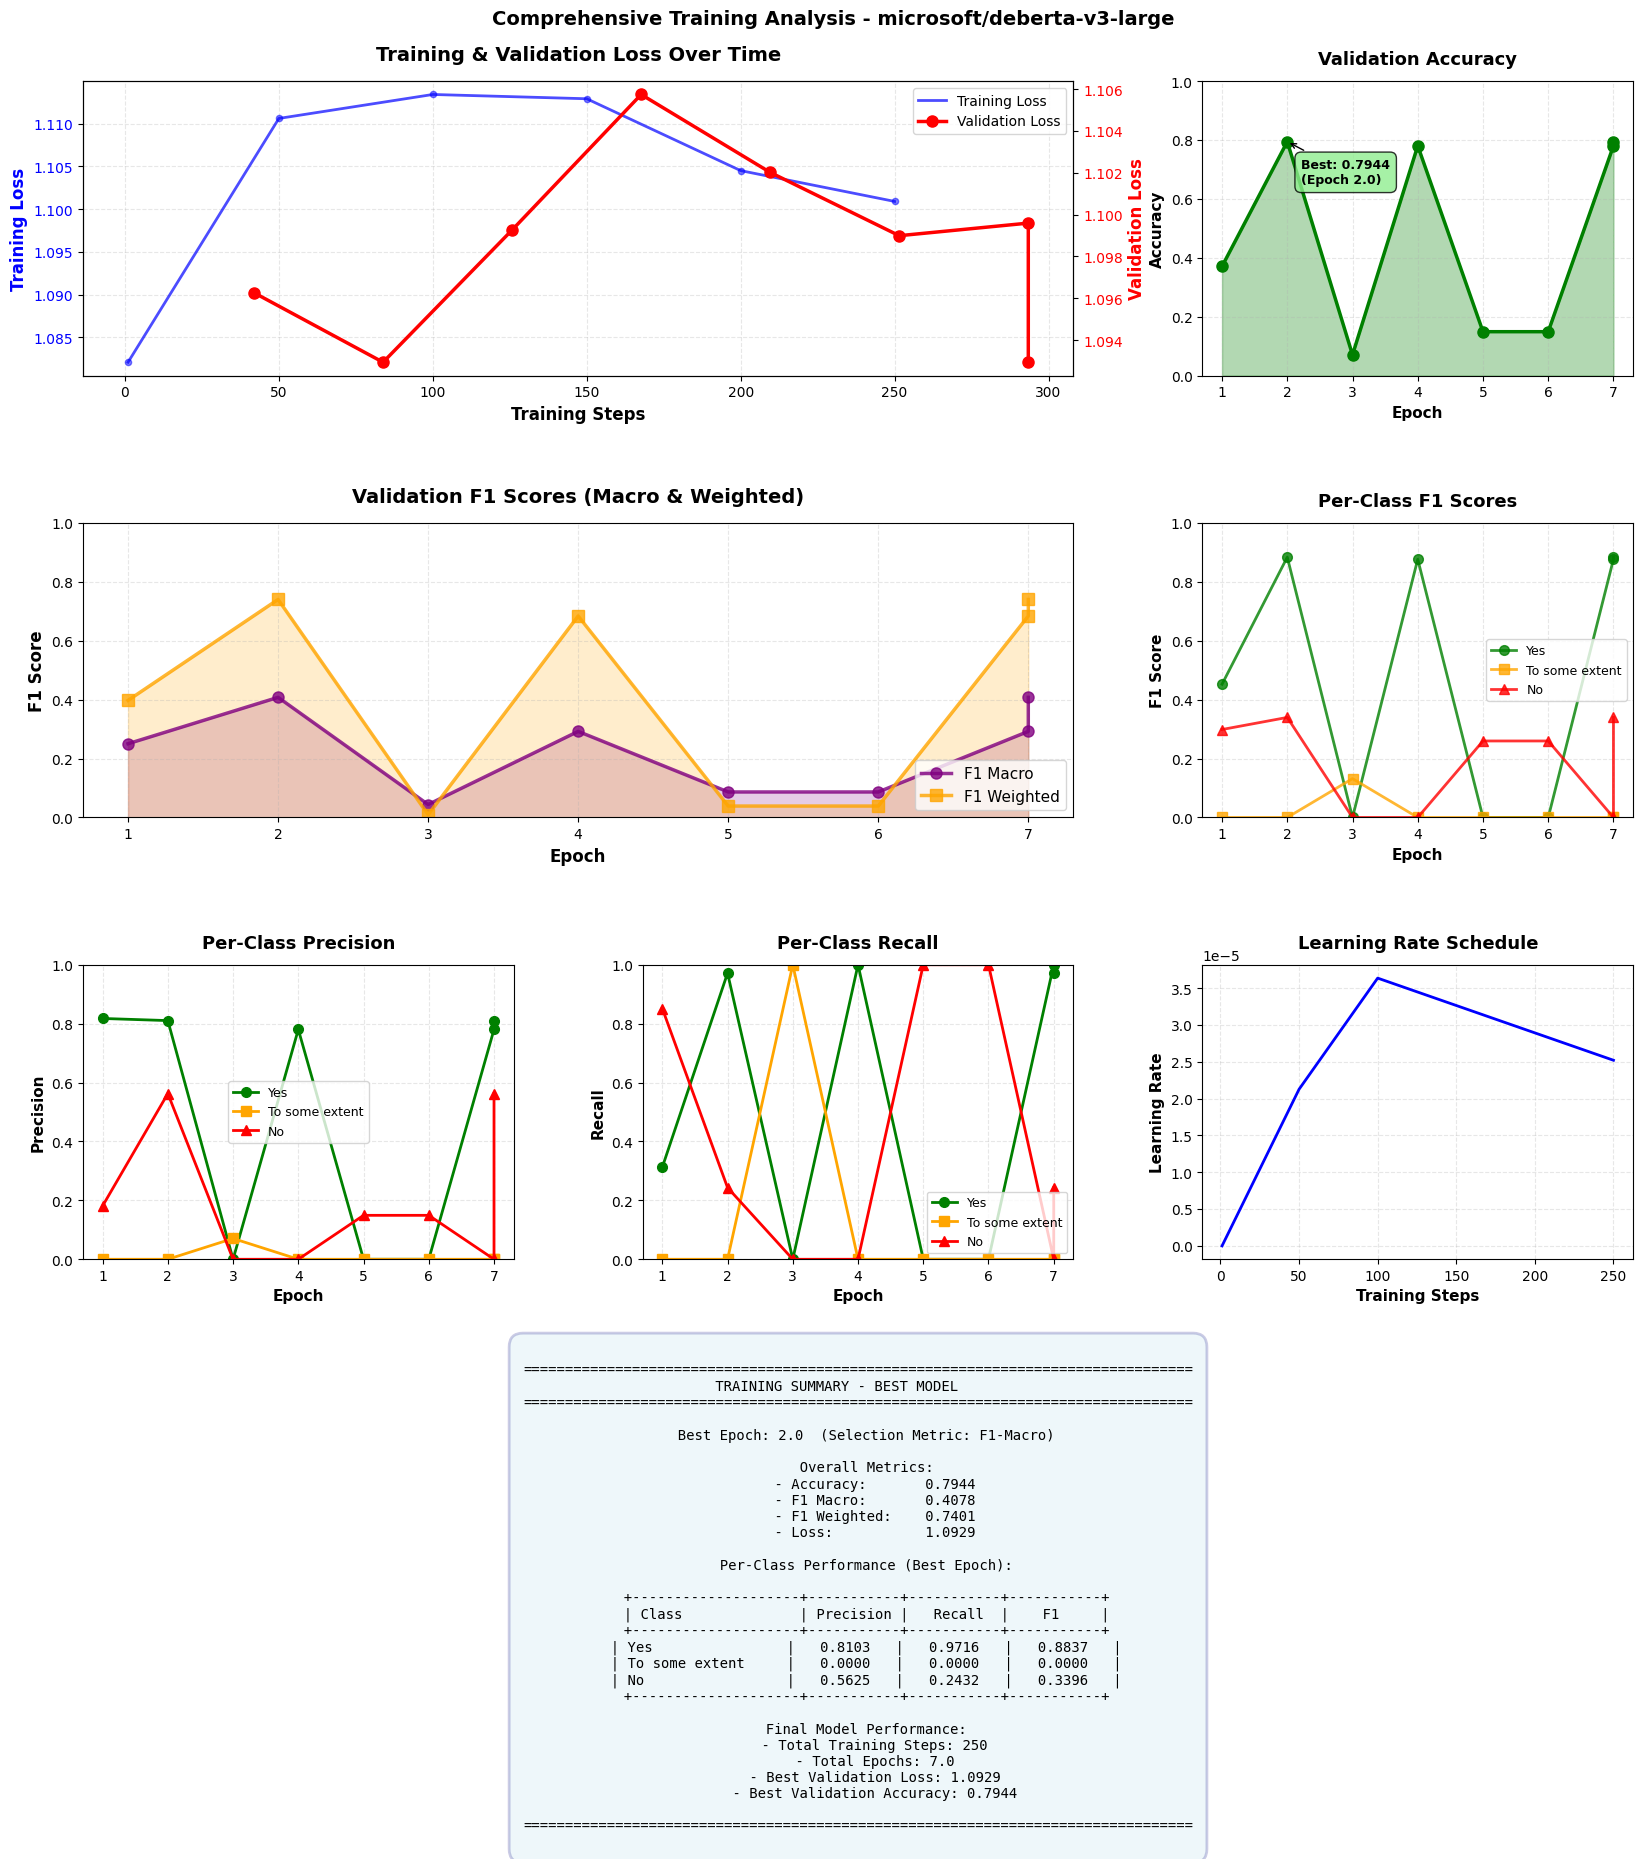


✓ Training curves saved to: training_curves_comprehensive.png

✓ Training history saved to: training_history.json


In [23]:
# ============================================================================
# COMPREHENSIVE TRAINING ANALYSIS & VISUALIZATION
# ============================================================================
import json
import os

print("="*80)
print("EXTRACTING TRAINING HISTORY")
print("="*80)

# Get the training history from the trainer
log_history = trainer.state.log_history

# Separate training and validation logs
train_logs = []
eval_logs = []

for entry in log_history:
    if 'loss' in entry and 'epoch' in entry:
        train_logs.append(entry)
    if 'eval_loss' in entry and 'epoch' in entry:
        eval_logs.append(entry)

print(f"Training steps logged: {len(train_logs)}")
print(f"Evaluation epochs logged: {len(eval_logs)}")

# Check if we have any evaluation data
if len(eval_logs) == 0:
    print("\n" + "="*80)
    print("⚠️  NO EVALUATION DATA AVAILABLE YET")
    print("="*80)
    print("Training has not completed any evaluation epochs.")
    print("Evaluation happens at the end of each epoch.")
    print("\nPlease wait for at least one epoch to complete before running this cell.")
    print("="*80)
else:
    # Extract data for plotting
    train_steps = [log['step'] for log in train_logs if 'step' in log]
    train_losses = [log['loss'] for log in train_logs if 'loss' in log]
    train_epochs = [log['epoch'] for log in train_logs if 'epoch' in log]

    eval_epochs = [log['epoch'] for log in eval_logs]
    eval_losses = [log['eval_loss'] for log in eval_logs]
    eval_accuracies = [log['eval_accuracy'] for log in eval_logs]
    eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]
    eval_f1_weighted = [log['eval_f1_weighted'] for log in eval_logs]

    # Per-class F1 scores
    eval_f1_yes = [log['eval_f1_yes'] for log in eval_logs]
    eval_f1_to_some_extent = [log['eval_f1_to_some_extent'] for log in eval_logs]
    eval_f1_no = [log['eval_f1_no'] for log in eval_logs]

    # Per-class precision and recall
    eval_precision_yes = [log['eval_precision_yes'] for log in eval_logs]
    eval_precision_to_some_extent = [log['eval_precision_to_some_extent'] for log in eval_logs]
    eval_precision_no = [log['eval_precision_no'] for log in eval_logs]

    eval_recall_yes = [log['eval_recall_yes'] for log in eval_logs]
    eval_recall_to_some_extent = [log['eval_recall_to_some_extent'] for log in eval_logs]
    eval_recall_no = [log['eval_recall_no'] for log in eval_logs]

    print(f"\n✓ Training history extracted successfully!")
    print("="*80)

    # ============================================================================
    # CREATE COMPREHENSIVE VISUALIZATION
    # ============================================================================

    fig = plt.figure(figsize=(20, 18))
    gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.3, top=0.94, bottom=0.04)

    # ============================================================================
    # 1. TRAINING & VALIDATION LOSS
    # ============================================================================
    ax1 = fig.add_subplot(gs[0, :2])
    ax1_twin = ax1.twinx()

    # Plot training loss (steps)
    if train_steps and train_losses:
        line1 = ax1.plot(train_steps, train_losses, 'b-', linewidth=2, alpha=0.7, label='Training Loss')
        ax1.scatter(train_steps, train_losses, c='blue', s=20, alpha=0.5, zorder=5)

    # Plot validation loss (epochs) on same axis
    if eval_epochs and eval_losses:
        # Convert epochs to approximate steps for alignment
        steps_per_epoch = max(train_steps) / max(train_epochs) if train_epochs and train_steps else 1
        eval_steps = [epoch * steps_per_epoch for epoch in eval_epochs]
        line2 = ax1_twin.plot(eval_steps, eval_losses, 'r-', linewidth=2.5, 
                              marker='o', markersize=8, label='Validation Loss')

    ax1.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Training Loss', fontsize=12, fontweight='bold', color='blue')
    ax1_twin.set_ylabel('Validation Loss', fontsize=12, fontweight='bold', color='red')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1_twin.tick_params(axis='y', labelcolor='red')
    ax1.set_title('Training & Validation Loss Over Time', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_twin.get_legend_handles_labels()
    if lines1 or lines2:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

    # ============================================================================
    # 2. VALIDATION ACCURACY
    # ============================================================================
    ax2 = fig.add_subplot(gs[0, 2])
    if eval_epochs and eval_accuracies:
        ax2.plot(eval_epochs, eval_accuracies, 'g-', linewidth=2.5, marker='o', markersize=8)
        ax2.fill_between(eval_epochs, eval_accuracies, alpha=0.3, color='green')
        
        # Add min/max annotations
        max_acc_idx = np.argmax(eval_accuracies)
        ax2.annotate(f'Best: {eval_accuracies[max_acc_idx]:.4f}\n(Epoch {eval_epochs[max_acc_idx]:.1f})',
                    xy=(eval_epochs[max_acc_idx], eval_accuracies[max_acc_idx]),
                    xytext=(10, -30), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black'),
                    fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax2.set_title('Validation Accuracy', fontsize=13, fontweight='bold', pad=12)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_ylim([0, 1.0])

    # ============================================================================
    # 3. F1 SCORES (MACRO & WEIGHTED)
    # ============================================================================
    ax3 = fig.add_subplot(gs[1, :2])
    if eval_epochs and eval_f1_macro:
        ax3.plot(eval_epochs, eval_f1_macro, 'purple', linewidth=2.5, marker='o', 
                 markersize=8, label='F1 Macro', alpha=0.8)
        ax3.plot(eval_epochs, eval_f1_weighted, 'orange', linewidth=2.5, marker='s', 
                 markersize=8, label='F1 Weighted', alpha=0.8)
        ax3.fill_between(eval_epochs, eval_f1_macro, alpha=0.2, color='purple')
        ax3.fill_between(eval_epochs, eval_f1_weighted, alpha=0.2, color='orange')
        ax3.legend(loc='lower right', fontsize=11)
    
    ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax3.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax3.set_title('Validation F1 Scores (Macro & Weighted)', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_ylim([0, 1.0])

    # ============================================================================
    # 4. PER-CLASS F1 SCORES
    # ============================================================================
    ax4 = fig.add_subplot(gs[1, 2])
    if eval_epochs and eval_f1_yes:
        ax4.plot(eval_epochs, eval_f1_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes', alpha=0.8)
        ax4.plot(eval_epochs, eval_f1_to_some_extent, 'orange', linewidth=2, marker='s', 
                 markersize=7, label='To some extent', alpha=0.8)
        ax4.plot(eval_epochs, eval_f1_no, 'r-', linewidth=2, marker='^', markersize=7, label='No', alpha=0.8)
        ax4.legend(loc='best', fontsize=9)
    
    ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax4.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
    ax4.set_title('Per-Class F1 Scores', fontsize=13, fontweight='bold', pad=12)
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_ylim([0, 1.0])

    # ============================================================================
    # 5. PER-CLASS PRECISION
    # ============================================================================
    ax5 = fig.add_subplot(gs[2, 0])
    if eval_epochs and eval_precision_yes:
        ax5.plot(eval_epochs, eval_precision_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes')
        ax5.plot(eval_epochs, eval_precision_to_some_extent, 'orange', linewidth=2, 
                 marker='s', markersize=7, label='To some extent')
        ax5.plot(eval_epochs, eval_precision_no, 'r-', linewidth=2, marker='^', markersize=7, label='No')
        ax5.legend(loc='best', fontsize=9)
    
    ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Precision', fontsize=11, fontweight='bold')
    ax5.set_title('Per-Class Precision', fontsize=13, fontweight='bold', pad=12)
    ax5.grid(True, alpha=0.3, linestyle='--')
    ax5.set_ylim([0, 1.0])

    # ============================================================================
    # 6. PER-CLASS RECALL
    # ============================================================================
    ax6 = fig.add_subplot(gs[2, 1])
    if eval_epochs and eval_recall_yes:
        ax6.plot(eval_epochs, eval_recall_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes')
        ax6.plot(eval_epochs, eval_recall_to_some_extent, 'orange', linewidth=2, 
                 marker='s', markersize=7, label='To some extent')
        ax6.plot(eval_epochs, eval_recall_no, 'r-', linewidth=2, marker='^', markersize=7, label='No')
        ax6.legend(loc='best', fontsize=9)
    
    ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Recall', fontsize=11, fontweight='bold')
    ax6.set_title('Per-Class Recall', fontsize=13, fontweight='bold', pad=12)
    ax6.grid(True, alpha=0.3, linestyle='--')
    ax6.set_ylim([0, 1.0])

    # ============================================================================
    # 7. LEARNING RATE SCHEDULE (if available)
    # ============================================================================
    ax7 = fig.add_subplot(gs[2, 2])
    if any('learning_rate' in log for log in train_logs):
        lr_steps = [log['step'] for log in train_logs if 'learning_rate' in log]
        learning_rates = [log['learning_rate'] for log in train_logs if 'learning_rate' in log]
        if lr_steps and learning_rates:
            ax7.plot(lr_steps, learning_rates, 'b-', linewidth=2)
            ax7.set_xlabel('Training Steps', fontsize=11, fontweight='bold')
            ax7.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
            ax7.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold', pad=12)
            ax7.grid(True, alpha=0.3, linestyle='--')
            ax7.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    else:
        ax7.text(0.5, 0.5, 'Learning Rate\nNot Logged', 
                ha='center', va='center', fontsize=12, transform=ax7.transAxes)
        ax7.set_xticks([])
        ax7.set_yticks([])

    # ============================================================================
    # 8. BEST METRICS SUMMARY (TEXT BOX) - IMPROVED LAYOUT
    # ============================================================================
    ax8 = fig.add_subplot(gs[3, :])
    ax8.axis('off')

    # Find best epoch
    if eval_f1_macro:
        best_epoch_idx = np.argmax(eval_f1_macro)
        best_epoch = eval_epochs[best_epoch_idx]

        # Create a well-formatted summary text with proper alignment
        summary_text = f"""
================================================================================
                      TRAINING SUMMARY - BEST MODEL                           
================================================================================

  Best Epoch: {best_epoch:.1f}  (Selection Metric: F1-Macro)

  Overall Metrics:
    - Accuracy:       {eval_accuracies[best_epoch_idx]:.4f}
    - F1 Macro:       {eval_f1_macro[best_epoch_idx]:.4f}
    - F1 Weighted:    {eval_f1_weighted[best_epoch_idx]:.4f}
    - Loss:           {eval_losses[best_epoch_idx]:.4f}

  Per-Class Performance (Best Epoch):
  
  +--------------------+-----------+-----------+-----------+
  | Class              | Precision |   Recall  |    F1     |
  +--------------------+-----------+-----------+-----------+
  | Yes                |   {eval_precision_yes[best_epoch_idx]:.4f}   |   {eval_recall_yes[best_epoch_idx]:.4f}   |   {eval_f1_yes[best_epoch_idx]:.4f}   |
  | To some extent     |   {eval_precision_to_some_extent[best_epoch_idx]:.4f}   |   {eval_recall_to_some_extent[best_epoch_idx]:.4f}   |   {eval_f1_to_some_extent[best_epoch_idx]:.4f}   |
  | No                 |   {eval_precision_no[best_epoch_idx]:.4f}   |   {eval_recall_no[best_epoch_idx]:.4f}   |   {eval_f1_no[best_epoch_idx]:.4f}   |
  +--------------------+-----------+-----------+-----------+

  Final Model Performance:
    - Total Training Steps: {max(train_steps) if train_steps else 0:,}
    - Total Epochs: {max(eval_epochs) if eval_epochs else 0:.1f}
    - Best Validation Loss: {min(eval_losses) if eval_losses else 0:.4f}
    - Best Validation Accuracy: {max(eval_accuracies) if eval_accuracies else 0:.4f}

================================================================================
"""

        ax8.text(0.5, 0.35, summary_text, 
                ha='center', va='center', fontsize=10, 
                family='monospace',
                bbox=dict(boxstyle='round,pad=1.0', facecolor='lightblue', alpha=0.2, edgecolor='navy', linewidth=2))

    plt.suptitle(f'Comprehensive Training Analysis - {MODEL_NAME}', 
                fontsize=14, fontweight='bold', y=0.98)

    plt.savefig('training_curves_comprehensive.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("✓ Training curves saved to: training_curves_comprehensive.png")
    print("="*80)

    # ============================================================================
    # ADDITIONAL: SAVE TRAINING HISTORY TO JSON
    # ============================================================================
    if eval_f1_macro:
        training_history = {
            'train_losses': train_losses,
            'train_steps': train_steps,
            'train_epochs': train_epochs,
            'eval_epochs': eval_epochs,
            'eval_losses': eval_losses,
            'eval_accuracies': eval_accuracies,
            'eval_f1_macro': eval_f1_macro,
            'eval_f1_weighted': eval_f1_weighted,
            'eval_f1_yes': eval_f1_yes,
            'eval_f1_to_some_extent': eval_f1_to_some_extent,
            'eval_f1_no': eval_f1_no,
            'eval_precision_yes': eval_precision_yes,
            'eval_precision_to_some_extent': eval_precision_to_some_extent,
            'eval_precision_no': eval_precision_no,
            'eval_recall_yes': eval_recall_yes,
            'eval_recall_to_some_extent': eval_recall_to_some_extent,
            'eval_recall_no': eval_recall_no,
            'best_epoch': float(best_epoch),
            'best_f1_macro': float(eval_f1_macro[best_epoch_idx]),
        }

        with open('training_history.json', 'w') as f:
            json.dump(training_history, f, indent=2)

        print("\n✓ Training history saved to: training_history.json")
        print("="*80)

## 11. Evaluate on Validation Set (from trainset)


***** Running Evaluation *****
  Num examples = 496
  Batch size = 48
  Num examples = 496
  Batch size = 48


VALIDATION SET EVALUATION (from trainset)




***** Running Prediction *****
  Num examples = 496
  Batch size = 48
  Num examples = 496
  Batch size = 48


Validation Set Metrics:
  Accuracy: 0.7944
  F1 (Macro): 0.4078
  F1 (Weighted): 0.7401

Per-Class F1 Scores:
  Yes: 0.8837
  To some extent: 0.0000
  No: 0.3396


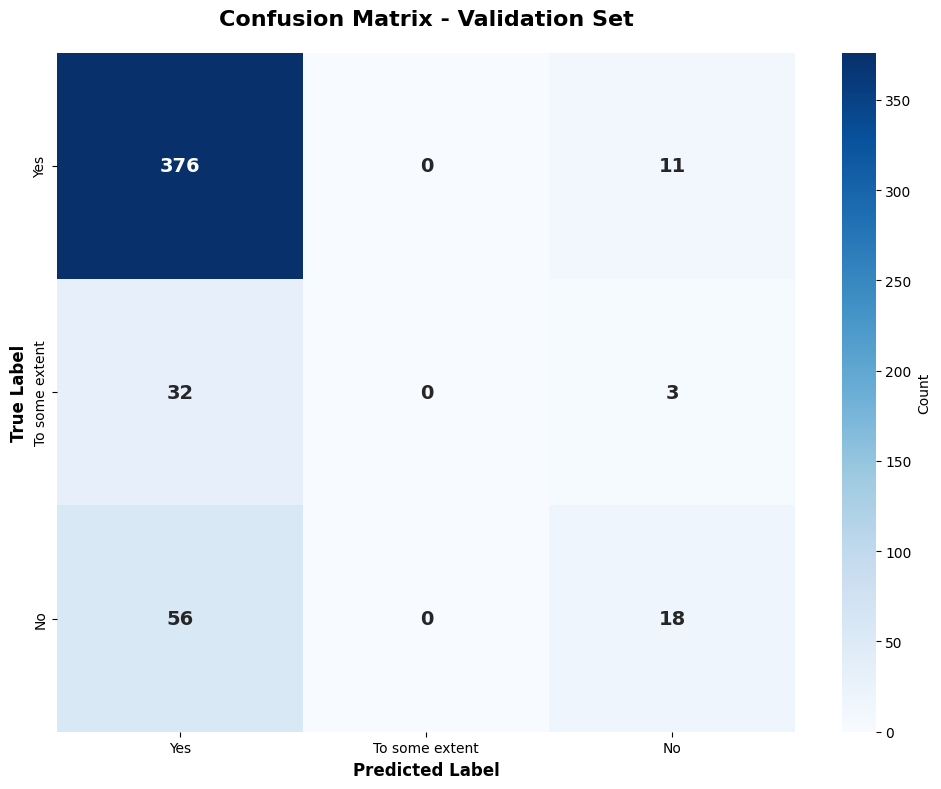


✓ Saved: confusion_matrix_validation.png

Classification Report - Validation Set
                precision    recall  f1-score   support

           Yes     0.8103    0.9716    0.8837       387
To some extent     0.0000    0.0000    0.0000        35
            No     0.5625    0.2432    0.3396        74

      accuracy                         0.7944       496
     macro avg     0.4576    0.4049    0.4078       496
  weighted avg     0.7162    0.7944    0.7401       496



In [24]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

## 12. Make Predictions on Dev and Test Sets (No Labels)

### 📝 Input Format for Predictions
The model uses the **same format** as training to ensure consistency:
- **With answer keys**: `[Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]`
- **Without answer keys**: `[Student Response] [SEP] [Tutor Response]` (fallback)

### 📂 Data Files Used
- **Dev set**: Attempts to load `dev_testset_with_answers.json` first, falls back to `dev_testset.json`
- **Test set**: Attempts to load `testset_with_answers.json` first, falls back to `testset.json`
- If either file is not found, that dataset is skipped

### 📊 Output Structure
The output CSV files maintain the **original structure** with all fields from input data plus predictions:
- `student_responses`: Extracted student text
- `answer_key`: Answer key (if available)
- `tutor_response`: Original tutor response
- `conversation_id`: Original conversation ID
- `model`: Model name
- **`predicted_label`**: Predicted class (Yes/To some extent/No)
- **`prob_yes`**: Probability for "Yes" class
- **`prob_to_some_extent`**: Probability for "To some extent" class
- **`prob_no`**: Probability for "No" class


***** Running Prediction *****
  Num examples = 1214
  Batch size = 48
  Num examples = 1214
  Batch size = 48



MAKING PREDICTIONS ON DEV & TEST SETS

Predicting on Dev set...



***** Running Prediction *****
  Num examples = 1214
  Batch size = 48
  Num examples = 1214
  Batch size = 48


✓ Dev predictions saved to: dev_predictions_student_responses_with_answers.csv (1214 samples)

Predicting on Test set...


✓ Test predictions saved to: test_predictions_student_responses_with_answers.csv (1214 samples)

Prediction Distribution

Dev Set:
Yes    1139
No       75
Name: count, dtype: int64

Test Set:
Yes    1139
No       75
Name: count, dtype: int64


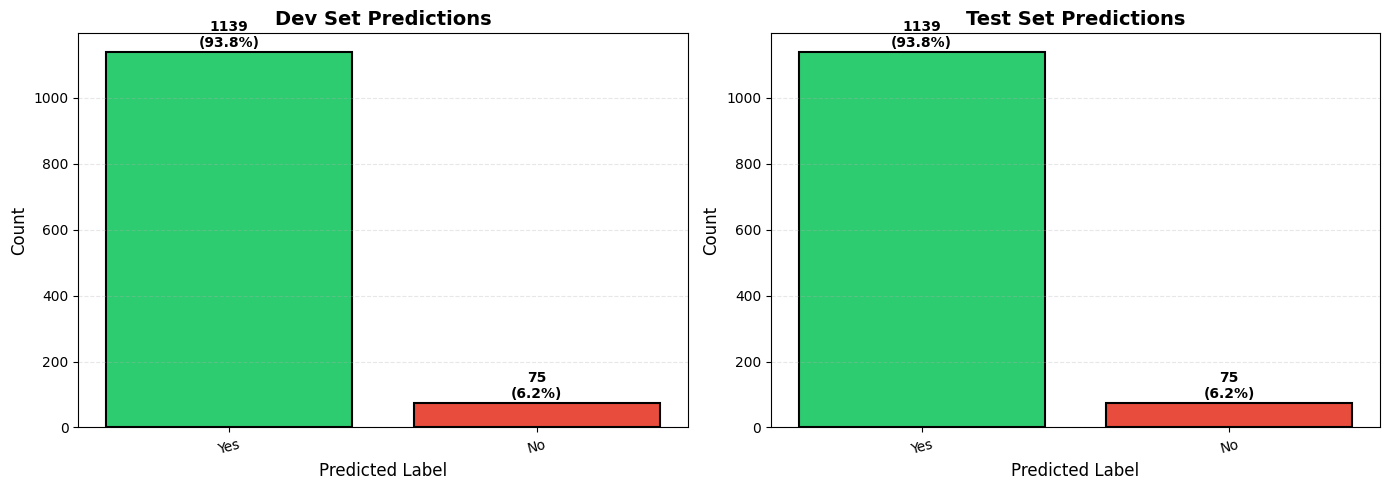


✓ Saved: prediction_distributions_student_responses_with_answers.png

Sample Predictions (Dev Set - First 5)

Sample 1:
  Student Responses: There were 18 - 8 = 10 girls assigned for the field trip. Sure. I started by subtracting 8 from 18 w...
  Answer Key: 1. We know that there were 18 students in total and 8 of them were boys.
2. This means that the numb...
  Tutor Response: It looks like there's still a bit of confusion, let's try to clarify - if the number of boys and gir...
  Predicted: Yes
  Confidence: 0.461
  ------------------------------------------------------------

Sample 2:
  Student Responses: There were 18 - 8 = 10 girls assigned for the field trip. Sure. I started by subtracting 8 from 18 w...
  Answer Key: 1. We know that there were 18 students in total and 8 of them were boys.
2. This means that the numb...
  Tutor Response: But you assumed x to be number of girls that didn't join the trip. And you calculated x =2...
  Predicted: Yes
  Confidence: 0.473
  ---------

In [25]:
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON DEV & TEST SETS")
print(f"{'='*60}\n")

# Initialize variables for tracking what was generated
dev_results_df = None
test_results_df = None
dev_pred_labels = None
test_pred_labels = None

# Make predictions on dev set (if available)
if dev_dataset is not None:
    print("Predicting on Dev set...")
    dev_predictions = trainer.predict(dev_dataset)
    dev_pred_labels = np.argmax(dev_predictions.predictions, axis=1)
    dev_pred_probs = torch.softmax(torch.tensor(dev_predictions.predictions), dim=1).numpy()
    
    # Add predictions to dev dataframe
    dev_results_df = dev_df.copy()
    dev_results_df['predicted_label'] = [id2label[label] for label in dev_pred_labels]
    dev_results_df['prob_yes'] = dev_pred_probs[:, 0]
    dev_results_df['prob_to_some_extent'] = dev_pred_probs[:, 1]
    dev_results_df['prob_no'] = dev_pred_probs[:, 2]
    
    # Save dev predictions
    output_file = 'dev_predictions_student_responses_with_answers.csv'
    dev_results_df.to_csv(output_file, index=False)
    print(f"✓ Dev predictions saved to: {output_file} ({len(dev_results_df)} samples)")
else:
    print("⚠️  Dev set not available - skipping dev predictions")

# Make predictions on test set (if available)
if test_dataset is not None:
    print("\nPredicting on Test set...")
    test_predictions = trainer.predict(test_dataset)
    test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
    test_pred_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()
    
    # Add predictions to test dataframe
    test_results_df = test_df.copy()
    test_results_df['predicted_label'] = [id2label[label] for label in test_pred_labels]
    test_results_df['prob_yes'] = test_pred_probs[:, 0]
    test_results_df['prob_to_some_extent'] = test_pred_probs[:, 1]
    test_results_df['prob_no'] = test_pred_probs[:, 2]
    
    # Save test predictions
    output_file = 'test_predictions_student_responses_with_answers.csv'
    test_results_df.to_csv(output_file, index=False)
    print(f"✓ Test predictions saved to: {output_file} ({len(test_results_df)} samples)")
else:
    print("⚠️  Test set not available - skipping test predictions")

# Show prediction distribution
if dev_pred_labels is not None or test_pred_labels is not None:
    print(f"\n{'='*60}")
    print("Prediction Distribution")
    print(f"{'='*60}")
    
    if dev_pred_labels is not None:
        print("\nDev Set:")
        print(pd.Series([id2label[label] for label in dev_pred_labels]).value_counts())
    
    if test_pred_labels is not None:
        print("\nTest Set:")
        print(pd.Series([id2label[label] for label in test_pred_labels]).value_counts())

    # Visualize prediction distributions
    num_plots = sum([dev_pred_labels is not None, test_pred_labels is not None])
    fig, axes = plt.subplots(1, num_plots, figsize=(7*num_plots, 5))
    if num_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    for pred_labels, name in [(dev_pred_labels, 'Dev'), (test_pred_labels, 'Test')]:
        if pred_labels is not None:
            pred_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()
            colors = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
                      for label in pred_counts.index]
            bars = axes[plot_idx].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.5)
            axes[plot_idx].set_title(f'{name} Set Predictions', fontsize=14, fontweight='bold')
            axes[plot_idx].set_ylabel('Count', fontsize=12)
            axes[plot_idx].set_xlabel('Predicted Label', fontsize=12)
            axes[plot_idx].tick_params(axis='x', rotation=15)
            axes[plot_idx].grid(axis='y', alpha=0.3, linestyle='--')
            
            for bar, count in zip(bars, pred_counts.values):
                height = bar.get_height()
                axes[plot_idx].text(bar.get_x() + bar.get_width()/2., height + 5,
                              f'{count}\n({count/len(pred_labels)*100:.1f}%)',
                              ha='center', va='bottom', fontweight='bold')
            plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('prediction_distributions_student_responses_with_answers.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Saved: prediction_distributions_student_responses_with_answers.png")

    # Show sample predictions (from whichever set is available)
    if dev_results_df is not None:
        print(f"\n{'='*60}")
        print("Sample Predictions (Dev Set - First 5)")
        print(f"{'='*60}")
        for i in range(min(5, len(dev_results_df))):
            row = dev_results_df.iloc[i]
            print(f"\nSample {i+1}:")
            print(f"  Student Responses: {row['student_responses'][:100]}...")
            if 'answer_key' in row and pd.notna(row['answer_key']):
                print(f"  Answer Key: {row['answer_key'][:100]}...")
            print(f"  Tutor Response: {row['tutor_response'][:100]}...")
            print(f"  Predicted: {row['predicted_label']}")
            print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
            print(f"  {'-'*60}")
    elif test_results_df is not None:
        print(f"\n{'='*60}")
        print("Sample Predictions (Test Set - First 5)")
        print(f"{'='*60}")
        for i in range(min(5, len(test_results_df))):
            row = test_results_df.iloc[i]
            print(f"\nSample {i+1}:")
            print(f"  Student Responses: {row['student_responses'][:100]}...")
            if 'answer_key' in row and pd.notna(row['answer_key']):
                print(f"  Answer Key: {row['answer_key'][:100]}...")
            print(f"  Tutor Response: {row['tutor_response'][:100]}...")
            print(f"  Predicted: {row['predicted_label']}")
            print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
            print(f"  {'-'*60}")
else:
    print("\n⚠️  No datasets available for prediction")

## 13. Training Summary & Results


TRAINING SUMMARY
Model: microsoft/deberta-v3-large
Training samples: 1980
Validation samples: 496

Validation Set Performance:
  Accuracy: 0.7944
  F1 (Macro): 0.4078
  F1 (Weighted): 0.7401

Per-Class F1 Scores:
  Yes: 0.8837
  To some extent: 0.0000
  No: 0.3396

PREDICTIONS GENERATED
✓ Dev set: 1214 predictions → dev_predictions_student_responses_with_answers.csv
✓ Test set: 1214 predictions → test_predictions_student_responses_with_answers.csv



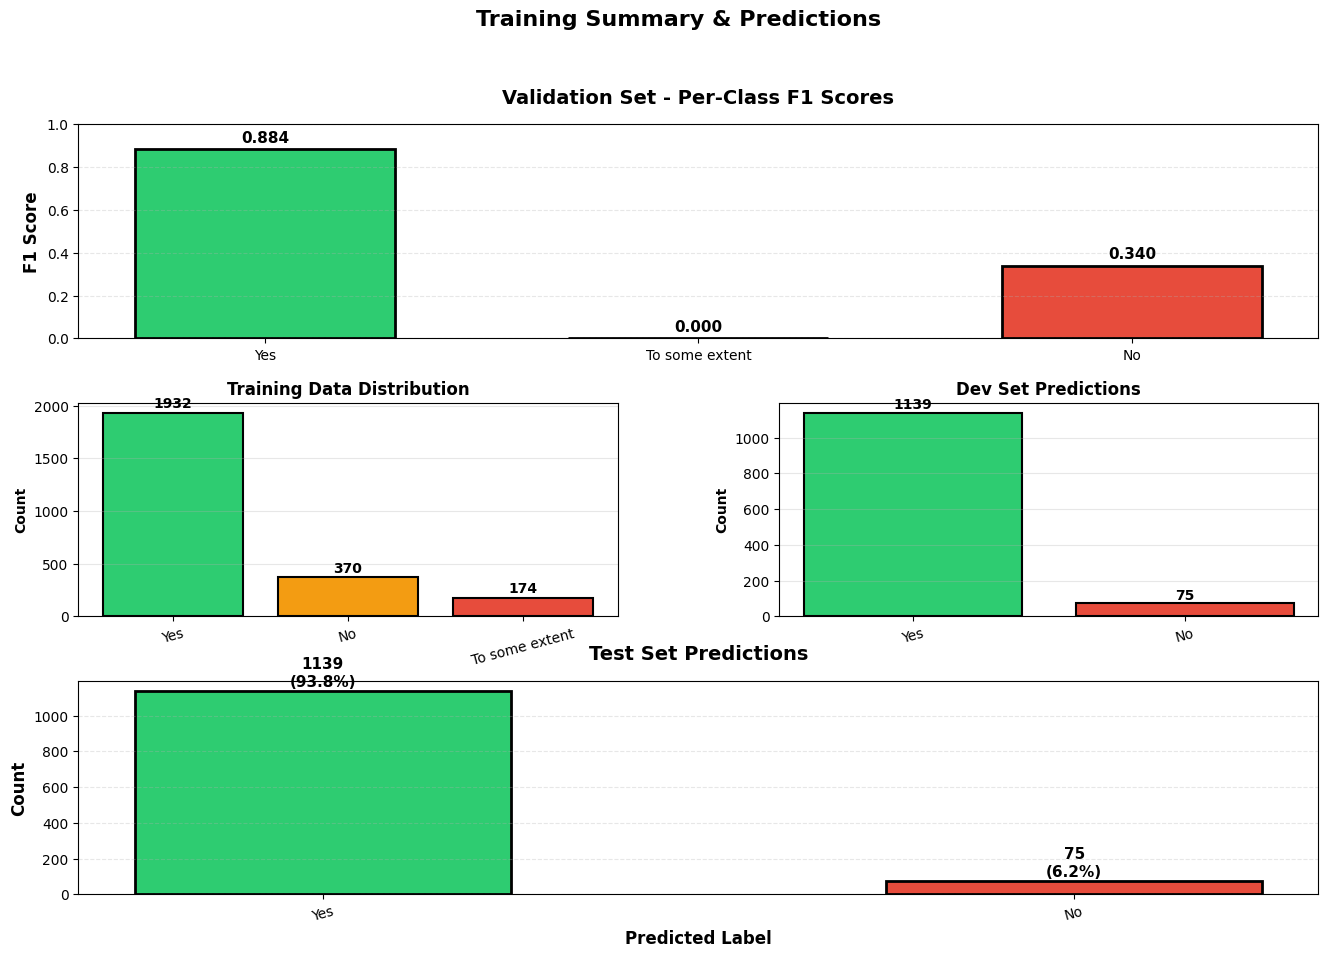

✓ Training summary visualization saved to: training_summary.png


In [26]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
if dev_results_df is not None:
    print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions_student_responses_with_answers.csv")
else:
    print(f"⚠️  Dev set: SKIPPED (file not available)")
    
if test_results_df is not None:
    print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions_student_responses_with_answers.csv")
else:
    print(f"⚠️  Test set: SKIPPED (file not available)")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
# Determine grid layout based on what predictions are available
has_dev = dev_pred_labels is not None
has_test = test_pred_labels is not None
num_pred_plots = sum([has_dev, has_test])

if num_pred_plots == 2:
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
elif num_pred_plots == 1:
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
else:
    # No predictions available
    fig = plt.figure(figsize=(16, 6))
    gs = fig.add_gridspec(2, 1, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

if num_pred_plots > 0:
    # 3. Dev/Test Set Predictions
    if has_dev:
        ax3 = fig.add_subplot(gs[1, 1])
        dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
        colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
                       for label in dev_pred_counts.index]
        bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
        ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
        ax3.set_ylabel('Count', fontweight='bold')
        ax3.tick_params(axis='x', rotation=15)
        ax3.grid(axis='y', alpha=0.3)
        for bar, count in zip(bars, dev_pred_counts.values):
            ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
                    ha='center', va='bottom', fontweight='bold')
    
    if has_test:
        # Test set on row 2 if both exist, or row 1 col 1 if only test exists
        if num_pred_plots == 2:
            ax4 = fig.add_subplot(gs[2, :])
        else:
            ax4 = fig.add_subplot(gs[1, 1])
        
        test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
        colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
                       for label in test_pred_counts.index]
        bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
        ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
        ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
        ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
        ax4.tick_params(axis='x', rotation=15)
        ax4.grid(axis='y', alpha=0.3, linestyle='--')
        for bar, count in zip(bars, test_pred_counts.values):
            ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
                    f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [27]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Input format: [Student Responses] + [Answer Key] + [Tutor Response]")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - results/mistake-identification-deberta/ → Trained model & tokenizer")
print(f"  - trainset_student_responses_with_answers.json → Processed training data")
print(f"  - dev_predictions_student_responses_with_answers.csv → Dev predictions")
print(f"  - test_predictions_student_responses_with_answers.csv → Test predictions")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions_student_responses_with_answers.png → Pred distributions")
print(f"  - training_summary.png → Complete training summary")
print(f"  - training_curves_comprehensive.png → Detailed training curves")
print(f"  - training_history.json → Training metrics history")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Compare with full conversation history approach")
print(f"  4. Evaluate impact of answer keys on classification")
print(f"  5. Use model for inference on new conversations")

print(f"\n{'='*80}\n")


🎉 TRAINING & PREDICTION COMPLETE!

✅ Model trained successfully on 1980 samples
✅ Input format: [Student Responses] + [Answer Key] + [Tutor Response]
✅ Validation F1-Macro: 0.4078
✅ Predictions generated for 1214 dev samples
✅ Predictions generated for 1214 test samples

📁 Output Files:
  - results/mistake-identification-deberta/ → Trained model & tokenizer
  - trainset_student_responses_with_answers.json → Processed training data
  - dev_predictions_student_responses_with_answers.csv → Dev predictions
  - test_predictions_student_responses_with_answers.csv → Test predictions
  - confusion_matrix_validation.png → Validation confusion matrix
  - prediction_distributions_student_responses_with_answers.png → Pred distributions
  - training_summary.png → Complete training summary
  - training_curves_comprehensive.png → Detailed training curves
  - training_history.json → Training metrics history
  - label_distribution.png → Training data distribution

📊 Next Steps:
  1. Review predictions

## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-large (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Input Features**: Student responses + Answer keys + Tutor responses
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Changes from Original
✓ **Uses trainset_with_answers.json** instead of regular trainset  
✓ **Extracts only student responses** from conversation history  
✓ **Includes answer keys** as additional context for the model  
✓ **New input format**: `[Student Response] [SEP] [Answer Key] [SEP] [Tutor Response]`  

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `student_responses` - Extracted student utterances
- `answer_key` - Correct answer (training only)
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Analyze how answer keys improve classification
3. Use the model for real-time inference
4. Fine-tune on additional labeled data if available
5. Deploy for production use

## 15. Create and Save Processed Training Dataset

Let's create and save a new version of the trainset with only student responses extracted.

In [28]:
import json

def create_processed_trainset(input_file, output_file):
    """
    Create a new trainset with only student responses extracted from conversation history.
    
    Output format:
    {
        "conversation_id": "...",
        "student_responses": "...",  # Only student utterances
        "answer_key": "...",  # Correct answer
        "tutor_responses": {
            "model_name": {
                "response": "...",
                "annotation": {...}
            }
        }
    }
    """
    with open(input_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    processed_data = []
    
    for conversation in data:
        conv_history = conversation['conversation_history']
        
        # Extract only student responses
        student_responses = extract_student_responses_from_conversation(conv_history)
        
        processed_conversation = {
            'conversation_id': conversation['conversation_id'],
            'student_responses': student_responses,
            'answer_key': conversation.get('answer_key', ''),
            'tutor_responses': conversation['tutor_responses']
        }
        
        processed_data.append(processed_conversation)
    
    # Save processed data
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(processed_data, f, indent=2, ensure_ascii=False)
    
    return len(processed_data)

# Create the processed trainset
print("="*80)
print("CREATING PROCESSED TRAINSET")
print("="*80)

input_file = 'trainset_with_answers.json'
output_file = 'trainset_student_responses_with_answers.json'

num_conversations = create_processed_trainset(input_file, output_file)

print(f"\n✓ Processed trainset created successfully!")
print(f"  Input: {input_file}")
print(f"  Output: {output_file}")
print(f"  Conversations: {num_conversations}")

# Verify the output
with open(output_file, 'r', encoding='utf-8') as f:
    processed_data = json.load(f)

print(f"\n{'='*80}")
print("SAMPLE FROM PROCESSED TRAINSET")
print(f"{'='*80}")

sample = processed_data[0]
print(f"\nConversation ID: {sample['conversation_id']}")
print(f"\nStudent Responses (extracted):")
print(f"{sample['student_responses'][:300]}...")
print(f"\nAnswer Key:")
print(f"{sample['answer_key'][:300]}...")
print(f"\nNumber of tutor responses: {len(sample['tutor_responses'])}")
print(f"Models: {', '.join(sample['tutor_responses'].keys())}")

print(f"\n{'='*80}")
print("✓ Processed trainset saved and verified!")
print(f"{'='*80}")

CREATING PROCESSED TRAINSET

✓ Processed trainset created successfully!
  Input: trainset_with_answers.json
  Output: trainset_student_responses_with_answers.json
  Conversations: 300

SAMPLE FROM PROCESSED TRAINSET

Conversation ID: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e

Student Responses (extracted):
To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches. Each sandwich requires 1 pound of meat and 1 pound of cheese. The cost of 1 pound of meat is $7.00....

Answer Key:
1. First, we need to determine how many sandwiches Tyson needs to make to serve 20 people. Since each sandwich serves 4 people, we divide the total number of people by the number of people served per sandwich:

Number of sandwiches = Total number of people / People served per sandwich
= 20 / 4
= 5 s...

Number of tutor responses: 8
Models: Sonnet, Llama318B, Llama31405B, GPT4, Mistral, Expert, Gemini, Phi3

✓ Processed trainset saved and verified!
